# Ch11- Time Series
<hr class="reddot">

In [95]:
%run "Ch00 - Basic Imports and Set ups.ipynb"

In [96]:
from datetime import datetime ,timedelta
from dateutil.parser import parse
import pytz

<div Class="green-box">
Time series data is an important form of structured data in many different fields, such
as finance, economics, ecology, neuroscience, and physics. **Anything that is observed
or measured at many points in time forms a time series.** Many time series are *fixed
frequency*, which is to say that data points occur at regular intervals according to some
rule, such as every 15 seconds, every 5 minutes, or once per month. Time series can
also be *irregular* without a fixed unit of time or offset between units. How you mark
and refer to time series data depends on the application, and you may have one of the
following:

* Timestamps, specific instants in time
* Fixed periods, such as the month January 2007 or the full year 2010
* Intervals of time, indicated by a start and end timestamp. Periods can be thought
of as special cases of intervals
* Experiment or elapsed time; each timestamp is a measure of time relative to a
particular start time (e.g., the diameter of a cookie baking each second since
being placed in the oven)

In this chapter, I am mainly concerned with time series in the first three categories,
though many of the techniques can be applied to experimental time series where the
index may be an integer or floating-point number indicating elapsed time from the
start of the experiment. The simplest and most widely used kind of time series are
those indexed by timestamp.

pandas also supports indexes based on timedeltas, which can be a
useful way of representing experiment or elapsed time. We do not
explore timedelta indexes in this book, but you can learn more in
the [pandas documentation](https://pandas.pydata.org/).

pandas provides many built-in time series tools and data algorithms. You can efficiently
work with very large time series and easily slice and dice, aggregate, and
resample irregular- and fixed-frequency time series. Some of these tools are especially
useful for financial and economics applications, but you could certainly use them to
analyze server log data, too.

<hr class="red-dot-line">

## 11.1 Date and Time Data Types and Tools

<hr class="reddot">

The Python standard library includes data types for date and time data, as well as
calendar-related functionality. The `datetime`, `time`, and `calendar` modules are the
main places to start. The `datetime.datetime` type, or simply `datetime`, is widely
used:

In [97]:
from datetime import datetime
from datetime import timedelta

In [98]:
now = datetime.now()

In [99]:
now

datetime.datetime(2026, 3, 22, 11, 1, 36, 596420)

In [100]:
now.year, now.month, now.day

(2026, 3, 22)

`datetime` stores both the date and time down to the microsecond. `timedelta` represents
the temporal difference between two `datetime` objects:

In [101]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)

In [102]:
delta

datetime.timedelta(days=926, seconds=56700)

In [103]:
delta.days

926

In [104]:
delta.seconds

56700

You can add (or subtract) a `timedelta` or multiple thereof to a `datetime` object to
yield a new shifted object:

In [105]:
from datetime import timedelta

In [106]:
start = datetime(2011, 1, 7)

In [107]:
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

In [108]:
start - 2 * timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

Table 11-1 summarizes the data types in the `datetime` module. While this chapter is
mainly concerned with the data types in pandas and higher-level time series manipulation,
you may encounter the datetime-based types in many other places in Python
in the wild.

In [109]:
columns = ["Type", "Description"]

rows = [
["date","Store calendar date (year, month, day) using the Gregorian calendar"],
["time","Store time of day as hours, minutes, seconds, and microseconds"],
["datetime","Store both date and time"],
["timedelta","Represent difference between two datetime values"],
["tzinfo","Base type for storing time zone information"]
]

render_book_table(
    "Table 11-1. Types in datetime Module",
    columns,
    rows
)

Type,Description
date,"Store calendar date (year, month, day) using the Gregorian calendar"
time,"Store time of day as hours, minutes, seconds, and microseconds"
datetime,Store both date and time
timedelta,Represent difference between two datetime values
tzinfo,Base type for storing time zone information


### Converting Between String and Datetime

You can format `datetime` objects and pandas `Timestamp` objects, which I’ll introduce
later, as strings using `str` or the `strftime` method, passing a `format` specification:

In [110]:
stamp = datetime(2011, 1, 3)

In [111]:
str(stamp)

'2011-01-03 00:00:00'

In [112]:
stamp.strftime('%Y-%m-%d')

'2011-01-03'

See Table 11-2 for a complete list of the format codes (reproduced from Chapter 2).

In [113]:
columns = ["Type", "Description"]

rows = [
["%Y","Four-digit year"],
["%y","Two-digit year"],
["%m","Two-digit month [01, 12]"],
["%d","Two-digit day [01, 31]"],
["%H","Hour (24-hour clock) [00, 23]"],
["%I","Hour (12-hour clock) [01, 12]"],
["%M","Two-digit minute [00, 59]"],
["%S","Second [00, 61] (accounts for leap seconds)"],
["%w","Weekday as integer [0 (Sunday), 6]"],
["%U","Week number (Sunday first day; days before first Sunday → week 0)"],
["%W","Week number (Monday first day; days before first Monday → week 0)"],
["%z","UTC offset as +HHMM or -HHMM"],
["%F","Shortcut for %Y-%m-%d"],
["%D","Shortcut for %m/%d/%y"]
]

render_book_table(
    "Table 11-2. Datetime Format Specification (ISO C89 Compatible)",
    columns,
    rows
)

Type,Description
%Y,Four-digit year
%y,Two-digit year
%m,"Two-digit month [01, 12]"
%d,"Two-digit day [01, 31]"
%H,"Hour (24-hour clock) [00, 23]"
%I,"Hour (12-hour clock) [01, 12]"
%M,"Two-digit minute [00, 59]"
%S,"Second [00, 61] (accounts for leap seconds)"
%w,"Weekday as integer [0 (Sunday), 6]"
%U,Week number (Sunday first day; days before first Sunday → week 0)


You can use these same format codes to convert strings to dates using date `time.strptime`

In [114]:
value = '2011-01-03'

In [115]:
datetime.strptime(value, '%Y-%m-%d')

datetime.datetime(2011, 1, 3, 0, 0)

In [116]:
datestrs = ['7/6/2011', '8/6/2011']

In [117]:
y=[datetime.strptime(x, '%m/%d/%Y') for x in datestrs]

In [118]:
y

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

`datetime.strptime` is a good way to parse a date with a known format. However, it
can be a bit annoying to have to write a format spec each time, especially for common
date formats. In this case, you can use the `parser.parse` method in the third-party
`dateutil` package (this is installed automatically when you install pandas):

In [119]:
from dateutil.parser import parse

In [120]:
parse('2011-01-03')

datetime.datetime(2011, 1, 3, 0, 0)

`dateutil` is capable of parsing most human-intelligible date representations:

In [121]:
parse('Jan 31, 1997 10:45 PM')

datetime.datetime(1997, 1, 31, 22, 45)

In international locales, day appearing before month is very common, so you can pass
`dayfirst=True` to indicate this:

In [122]:
parse('6/12/2011', dayfirst=True)

datetime.datetime(2011, 12, 6, 0, 0)

pandas is generally oriented toward working with arrays of dates, whether used as an
axis index or a column in a DataFrame. The `to_datetime` method parses many different
kinds of date representations. Standard date formats like ISO 8601 can be
parsed very quickly:

In [123]:
datestrs = ['2011-07-06 12:00:00', '2011-08-06 00:00:00']

In [124]:
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

It also handles values that should be considered missing (None, empty string, etc.):

In [125]:
idx = pd.to_datetime(datestrs + [None])

In [126]:
idx

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [127]:
idx[2]

NaT

In [128]:
pd.isnull(idx)

array([False, False,  True])

<div class="blue-box">
`NaT` (Not a Time) is pandas’s null value for timestamp data.
</div> 

<div class="red-box">

##### 🚨

`dateutil.parser` is a useful but imperfect tool. Notably, it will recognize
some strings as dates that you might prefer that it didn’t—
for example, '42' will be parsed as the year 2042 with today’s calendar
date.

</div> 

`datetime` objects also have a number of locale-specific formatting options for systems
in other countries or languages. For example, the abbreviated month names will be
different on German or French systems compared with English systems. See
Table 11-3 for a listing.

In [129]:
columns = ["Type", "Description"]

rows = [
["%a","Abbreviated weekday name"],
["%A","Full weekday name"],
["%b","Abbreviated month name"],
["%B","Full month name"],
["%c","Full date and time (locale-specific format)"],
["%p","Locale equivalent of AM or PM"],
["%x","Locale-appropriate formatted date"],
["%X","Locale-appropriate formatted time"]
]

render_book_table(
    "Table 11-3. Locale-Specific Date Formatting",
    columns,
    rows
)

Type,Description
%a,Abbreviated weekday name
%A,Full weekday name
%b,Abbreviated month name
%B,Full month name
%c,Full date and time (locale-specific format)
%p,Locale equivalent of AM or PM
%x,Locale-appropriate formatted date
%X,Locale-appropriate formatted time


<details class="collapsible blue-box">
<summary>📘 Click to expand explanation for locale specific formatting</summary>

Important practical understanding for data science:

Locale formatting is mainly used for **presentation and reporting**, not for computation.

Example:

```python
dt.strftime("%A, %B %d")
```

Output:

```
Monday, March 21
```

Locale-dependent formatting:

```python
dt.strftime("%x")
```

In US locale → `05/01/2012`
In many European locales → `01/05/2012`

Best practice in real pipelines:

* Store timestamps internally in **ISO format (`%Y-%m-%d`)**
* Use locale formats only when generating **reports / dashboards / exports**
* Avoid locale-dependent parsing in ETL unless absolutely necessary (can introduce ambiguity)




## 11.2 Time Series Basics
<hr class="reddot">

A basic kind of time series object in pandas is a Series indexed by timestamps, which
is often represented external to pandas as Python strings or `datetime` objects:

In [130]:
from datetime import datetime

In [131]:
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]

In [132]:
ts = pd.Series(np.random.randn(6), index=dates)

In [133]:
ts

2011-01-02   -0.066021
2011-01-05   -0.294281
2011-01-07   -0.235430
2011-01-08    0.908719
2011-01-10   -1.520041
2011-01-12   -0.188807
dtype: float64

Under the hood, these `datetime` objects have been put in a `DatetimeIndex`:

In [134]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

<div class="blue-box"> 
pandas stores timestamps using NumPy’s `datetime64` data type at the nanosecond
resolution:
</div> 

<details class="collapsible blue-box">
<summary>📘 Click to expand how Numpy stores time </summary>
Conceptual Definition

NumPy’s **`datetime64`** is an **integer-based time representation**.

Internally it is:

> A **signed 64-bit integer counting time units from a fixed epoch (1970-01-01T00:00:00 UTC)**
> together with **metadata specifying the time unit**.

So a datetime64 value is not stored as:

```
(year, month, day, hour…)
```

Instead it is stored as:

```
(int64 value) + (time unit metadata)
```

---

#### Internal Structure

You can mentally model it as:

```
datetime64 = (int64_value , unit)
```

Example:

```python
np.datetime64('2024-01-01')
```

Internally becomes something like:

```
19723 days since 1970-01-01
```

if the inferred unit is **days (`D`)**.

---

#### Epoch Reference

NumPy uses:

```
Unix epoch → 1970-01-01 00:00:00
```

So:

```
np.datetime64('1970-01-01') → integer value = 0
```

---

#### Time Unit Metadata (VERY Important)

datetime64 supports multiple resolutions.

Examples:

| Unit | Meaning      |
| ---- | ------------ |
| `Y`  | years        |
| `M`  | months       |
| `D`  | days         |
| `h`  | hours        |
| `m`  | minutes      |
| `s`  | seconds      |
| `ms` | milliseconds |
| `us` | microseconds |
| `ns` | nanoseconds  |

So these are **different physical dtypes**:

```python
datetime64[D]
datetime64[s]
datetime64[ns]
```

---

#### Example Showing Internal Behavior

```python
arr = np.array(['1970-01-02'], dtype='datetime64[D]')
```

Internally:

```
stored integer = 1
unit = day
```

Because it is **1 day after epoch**.

---

#### Why This Design Matters (Architect View)

This design gives NumPy:

##### 1. Extremely fast arithmetic

```python
arr + 5
```

Means:

```
integer + 5 units
```

No calendar parsing needed.

---

##### 2. Vectorization

Time differences become simple subtraction:

```python
arr2 - arr1
```

Internally:

```
int64 − int64 → timedelta64
```

---

##### 3. Memory efficiency

Each timestamp:

```
8 bytes only
```

Compare:

* Python `datetime` → object pointer + object → much heavier
* pandas Timestamp → wrapper over int64

---

#### Important Limitation

Because it is integer + unit:

* calendar logic like leap months / DST is **not encoded**
* timezone is **not stored**

This is why pandas adds richer time handling.

---

#### Relationship to timedelta64

Difference between two datetime64 values:

```
datetime64 − datetime64 → timedelta64
```

Which is also:

```
(int64_value , unit)
```

---

#### Deep Mental Model (Very High Value)

Think of NumPy temporal system as:

```
datetime64 → absolute time point (int64 + unit)

timedelta64 → time duration (int64 + unit)
```

So time in NumPy is treated like:

> **A numeric axis with units**

Exactly like meters or seconds in physics simulation.

---

If you want next, I can explain a **very important and tricky concept**:

👉 Why `datetime64[M]` (month unit) behaves very differently from `datetime64[D]`
This confuses even experienced data scientists.


<hr class="red-dot-line">

Like other Series, arithmetic operations between differently indexed time series automatically
align on the dates:

In [135]:
ts + ts[::2]

2011-01-02   -0.132041
2011-01-05         NaN
2011-01-07   -0.470860
2011-01-08         NaN
2011-01-10   -3.040083
2011-01-12         NaN
dtype: float64

In [136]:
ts[::2]

2011-01-02   -0.066021
2011-01-07   -0.235430
2011-01-10   -1.520041
dtype: float64

<details class="collapsible blue-box">
<summary>📘 Explanation </summary>
<span class="big-icon"> ✅ </span> Why `ts + ts[::2]` produces **NaN** in some rows

This behaviour comes from one of the **most important design principles in pandas:
👉 *Automatic alignment by index labels.*** 

Let’s understand step-by-step.

---

##### 🔹 Step 1 — What is `ts` ?

You created a **time-indexed Series**:

```python
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]

ts = pd.Series(np.random.randn(6), index=dates)
```

So index looks like:

```
2011-01-02
2011-01-05
2011-01-07
2011-01-08
2011-01-10
2011-01-12
```

---

##### 🔹 Step 2 — What is `ts[::2]` ?

This means:

👉 **Take every 2nd element (step = 2)**

So new Series becomes:

```
2011-01-02
2011-01-07
2011-01-10
```

Very important:

⚠️ This Series **does NOT contain the other dates**

Missing:

```
2011-01-05
2011-01-08
2011-01-12
```

---

##### 🔹 Step 3 — What happens during `ts + ts[::2]` ?

Pandas does **label-based alignment BEFORE doing arithmetic**

Conceptually pandas does:

```
Union of indexes
↓
Match values by index
↓
Add where both exist
↓
If one side missing → NaN
```

---

##### 🔹 Visual Alignment Table (VERY IMPORTANT)

| Date   | ts value | ts[::2] value | Result        |
| ------ | -------- | ------------- | ------------- |
| Jan-02 | ✓        | ✓             | value + value |
| Jan-05 | ✓        | ❌             | NaN           |
| Jan-07 | ✓        | ✓             | value + value |
| Jan-08 | ✓        | ❌             | NaN           |
| Jan-10 | ✓        | ✓             | value + value |
| Jan-12 | ✓        | ❌             | NaN           |

So:

👉 Wherever **index not present in ts[::2] → NaN**

Because:

```
number + missing = NaN
```

---

##### 🔹 Key Mental Model (Senior DS Architect Insight)

Think:

> **Pandas arithmetic is like SQL outer join on index**

Not like NumPy positional addition.

NumPy would do:

```
[ a b c d e f ] + [ a c e ]
```

But pandas does:

```
JOIN ON INDEX LABELS
```

This is why pandas is powerful for **time-series + real world messy data**

---

##### 🔹 If you wanted positional addition instead

You must ignore index:

```python
ts.values + ts[::2].values
```

But this will:

⚠️ likely error due to different lengths.

Or force reindex:

```python
ts + ts[::2].reindex(ts.index)
```

---

##### ✅ Final One-Line Understanding

> `NaN` appears because pandas aligns by **date labels**, and for some dates the sliced Series has **no matching value**.

---

If you want, I can next show you a **diagram showing how pandas builds the union index internally** — that makes this concept permanently clear 👍


In [137]:
ts.index.dtype

dtype('<M8[ns]')

Scalar values from a `DatetimeIndex` are pandas `Timestamp` objects:

In [138]:
stamp = ts.index[0]

In [139]:
stamp

Timestamp('2011-01-02 00:00:00')

A `Timestamp` can be substituted anywhere you would use a `datetime` object. Additionally,
it can store frequency information (if any) and understands how to do time
zone conversions and other kinds of manipulations. More on both of these things
later.

### Indexing, Selection, Subsetting

Time series behaves like any other `pandas.Series` when you are indexing and selecting
data based on label:

In [140]:
ts

2011-01-02   -0.066021
2011-01-05   -0.294281
2011-01-07   -0.235430
2011-01-08    0.908719
2011-01-10   -1.520041
2011-01-12   -0.188807
dtype: float64

In [141]:
stamp = ts.index[2]

In [99]:
ts[stamp]

np.float64(0.7702359526556418)

As a convenience, you can also pass a string that is interpretable as a date:

In [101]:
ts['1/10/2011']

np.float64(0.6916546008706402)

In [103]:
ts['1/10/11']

np.float64(0.6916546008706402)

In [104]:
ts['01/10/11']

np.float64(0.6916546008706402)

In [107]:
ts['20110110']

np.float64(0.6916546008706402)

In [108]:
ts['20111001']

KeyError: '20111001'

<div class="blue-box"> When an idex value is not there in the Series, it gives error. </div>

<details class="collapsible blue-box">

<summary>📘 Why `'20110110'` is **NOT treated as 20-Nov-0110 </summary>

##### ✅ Why `'20110110'` is **NOT treated as 20-Nov-0110**

This confusion is very natural 👍 — because we humans can read numbers in many ways.

But pandas follows **strict datetime parsing rules.**

Let’s understand clearly.

---

##### 🔵 How pandas interprets `'20110110'`

When you write:

```python
ts['20110110']
```

pandas sends this string to its datetime parser.

Default rule used is:

> **YYYYMMDD (ISO-like interpretation)**

So:

```
20110110
↓
Year   = 2011
Month  = 01
Day    = 1011.3 Date Ranges, Frequencies, and Shifting
```

Therefore pandas converts it to:

```
Timestamp('2011-01-10')
```

NOT anything else.

---

##### 🔵 Why NOT Month = 11 ?

Because that would require parsing like:

```
DDMMYYYY
MMDDYYYY
or some mixed pattern
```

But pandas does **not guess randomly.**

It follows:

✅ ISO standard preference
✅ unambiguous ordering
✅ deterministic parsing

Otherwise time-series code would become dangerous.

Imagine:

```
'03042021'
```

Is it:

* 3 Apr ?
* 4 Mar ?
* Year 3021 ?
* Day 30 Month 4 ?

So pandas uses a **fixed safe rule.**

---

##### 🔵 Why NOT Year = 0110 ?

Because:

```
Year must be first 4 digits
```

So pandas reads:

```
2011 → valid modern year
```

Not:

```
0110 → ancient year
```

Also internally pandas stores datetime as:

👉 **nanoseconds since 1970 (int64)**

So modern years are expected unless explicitly specified.

---

##### 🔵 If you WANT different interpretation

You must tell pandas explicitly.

Example:

###### ✅ Custom parsing

```python
pd.to_datetime('20110110', format='%d%m%Y')
```

Now it becomes:

```
20-Jan-0110
```

(if valid)

---

##### 🔵 Very important Time-Series Skill

There are **3 different ways strings become datetime in pandas**

| Situation       | Behaviour                       |
| --------------- | ------------------------------- |
| Index lookup    | strict ISO-like                 |
| `to_datetime()` | intelligent but configurable    |
| CSV reading     | depends on `dayfirst`, `format` |

Senior data scientists **always control format.**

---

##### ✅ Final Mental Model

> `'20110110'` is read as **YYYYMMDD → 10 Jan 2011** because pandas uses a fixed, safe, ISO-style parsing rule — it does not guess alternate date layouts.

---

If you want, I can next explain a SUPER IMPORTANT hidden feature:

🔥 Why `ts['2011']` works
🔥 Why `ts['2011-01']` works
🔥 But `ts['20110110']` behaves differently

This is a core pandas time-series indexing concept.


For longer time series, a year or only a year and month can be passed to easily select
slices of data:

In [111]:
longer_ts = pd.Series(np.random.randn(1000),index=pd.date_range('1/1/2000', periods=1000))

In [112]:
longer_ts

2000-01-01   -0.779988
2000-01-02   -0.334626
2000-01-03    0.583545
2000-01-04   -1.322250
2000-01-05    0.864992
                ...   
2002-09-22   -0.547231
2002-09-23   -0.424242
2002-09-24   -0.902536
2002-09-25   -0.179871
2002-09-26   -0.888977
Freq: D, Length: 1000, dtype: float64

In [113]:
longer_ts['2001']

2001-01-01   -0.824111
2001-01-02   -3.098216
2001-01-03    0.351731
2001-01-04    0.087198
2001-01-05    1.001339
                ...   
2001-12-27   -0.533726
2001-12-28    0.709714
2001-12-29   -2.062137
2001-12-30   -0.289298
2001-12-31    0.118856
Freq: D, Length: 365, dtype: float64

Here, the string '`2001'` is interpreted as a year and selects that time period. This also
works if you specify the month:

In [114]:
longer_ts['2001-05']

2001-05-01    0.037429
2001-05-02    0.743908
2001-05-03    0.560093
2001-05-04    0.877940
2001-05-05    0.783467
2001-05-06   -0.949991
2001-05-07    0.358975
2001-05-08   -0.058294
2001-05-09    0.889853
2001-05-10    0.934843
2001-05-11   -0.405380
2001-05-12   -0.289339
2001-05-13    1.712095
2001-05-14    0.172046
2001-05-15   -1.023560
2001-05-16   -0.044047
2001-05-17    0.655132
2001-05-18    1.994319
2001-05-19    0.581609
2001-05-20   -0.209969
2001-05-21   -1.092322
2001-05-22    0.266164
2001-05-23   -0.979979
2001-05-24   -2.118273
2001-05-25    0.214993
2001-05-26    0.322313
2001-05-27    1.073751
2001-05-28   -0.041301
2001-05-29   -0.530970
2001-05-30   -0.201720
2001-05-31    0.115641
Freq: D, dtype: float64

Slicing with `datetime`m objects works as well:

In [115]:
ts[datetime(2011, 1, 7):]

2011-01-07    0.770236
2011-01-08   -1.198226
2011-01-10    0.691655
2011-01-12   -1.413361
dtype: float64

Because most time series data is ordered chronologically, you can slice with timestamps
not contained in a time series to perform a range query:

In [116]:
ts

2011-01-02    0.250610
2011-01-05   -0.781928
2011-01-07    0.770236
2011-01-08   -1.198226
2011-01-10    0.691655
2011-01-12   -1.413361
dtype: float64

In [117]:
ts['1/6/2011':'1/11/2011']

2011-01-07    0.770236
2011-01-08   -1.198226
2011-01-10    0.691655
dtype: float64

but `ts['1/6/2011']` gives an error

In [119]:
ts['1/6/2011']

KeyError: '1/6/2011'

In [120]:
ts

2011-01-02    0.250610
2011-01-05   -0.781928
2011-01-07    0.770236
2011-01-08   -1.198226
2011-01-10    0.691655
2011-01-12   -1.413361
dtype: float64

As before, you can pass either a string date, `datetime`, or `timestamp`. Remember that
slicing in this manner produces views on the source time series like slicing NumPy
arrays. This means that no data is copied and modifications on the slice will be reflected
in the original data.

<details class="collapsible blue-box">

<summary>📘 'Explanation of copy vs View for Numpy Arrays and Time datatypes' </summary>
##### 📌 Context — What this statement is talking about

In **pandas time series**, you can select (slice) data using:

* string date → `"2011-01-10"`
* Python `datetime`
* pandas `Timestamp`

And when you slice a time series, **pandas often does NOT copy the data**.
Instead it creates a **view (like NumPy slicing)**. 

This is the key idea being explained.

---

##### 🧠 First — What is a *view* vs a *copy*

Think of memory like a big Excel sheet.

When you slice:

✅ **View → just another window looking at the SAME data**
❌ **Copy → a completely new duplicated dataset**

Example intuition:

* View = Opening same Excel file in another tab
* Copy = Saving “file_copy.xlsx”

---

##### 📊 Example — Time series slicing

```python
ts["2011-01-10":"2011-01-12"]
```

This usually returns a **view on the original time series**.

So:

```
Original data (memory)
      ↑
      │
Slice points here (no duplication)
```

---

##### ⚡ Why pandas / NumPy do this

Because copying large datasets is **expensive**:

* More RAM usage
* Slower performance
* Unnecessary duplication

So libraries like **NumPy and pandas optimize slicing → by returning views**.

---

##### 🔥 VERY IMPORTANT CONSEQUENCE

If you modify the slice…

👉 The original data ALSO changes.

Example:

```python
ts_slice = ts["2011-01-10":"2011-01-12"]

ts_slice[:] = 0
```

Now:

```python
ts
```

Will show those dates changed to **0**.

Because:

> Both variables point to the SAME underlying memory.

---

##### 🧩 Architecture-level mental model

Think like this (very important for Data Science engineering):

```
ts        ---> Memory Block A
ts_slice  ---^
```

Both references → **same memory**

So mutation through one reference → visible everywhere.

This is exactly how **NumPy ndarray slicing works**, and pandas builds on top of that.

---

##### ⚠️ But note — pandas is sometimes inconsistent

Unlike NumPy:

* Some operations return **view**
* Some return **copy**

This is why pandas gives:

```
SettingWithCopyWarning
```

Because it is unsure:

👉 Are you modifying original data or temporary copy?

Senior DS engineers always write safe code like:

```python
ts_slice = ts.loc["2011-01-10":"2011-01-12"].copy()
```

Now:

✅ Guaranteed independent dataset
✅ No accidental mutation

---

##### ✅ Final One-Line Understanding

> Time series slicing in pandas usually creates a **view (memory reference)** — so modifying the slice can modify the original data, since no physical copy of data was made.




There is an equivalent instance method, `truncate`, that slices a Series between two
dates:

In [122]:
ts.truncate(after='1/9/2011')

2011-01-02    0.250610
2011-01-05   -0.781928
2011-01-07    0.770236
2011-01-08   -1.198226
dtype: float64

In [123]:
ts

2011-01-02    0.250610
2011-01-05   -0.781928
2011-01-07    0.770236
2011-01-08   -1.198226
2011-01-10    0.691655
2011-01-12   -1.413361
dtype: float64

<hr class="red-dot-line">

All of this holds true for DataFrame as well, indexing on its rows:

In [125]:
dates = pd.date_range('1/1/2000', periods=100, freq='W-WED')


In [126]:

long_df = pd.DataFrame(np.random.randn(100, 4),
index=dates,
columns=['Colorado', 'Texas', 'New York', 'Ohio'])


In [127]:
long_df

,Colorado,Texas,New York,Ohio
2000-01-05,0.816002,-1.247965,-0.200261,1.917188
2000-01-12,0.580278,0.824685,0.738189,0.523165
2000-01-19,-0.470351,0.863344,1.060860,0.204518
2000-01-26,0.367894,0.408394,0.346899,-1.194499
2000-02-02,-0.948426,-1.895416,-0.434624,0.482335
...,...,...,...,...
2001-10-31,-0.239639,-0.090143,1.028004,2.023734
2001-11-07,0.031468,-1.131665,-1.051324,-0.156203
2001-11-14,1.389846,-1.386230,0.665461,-0.285764
2001-11-21,1.204224,-1.181914,0.306108,-0.024057


In [128]:
long_df.loc['5-2001']

,Colorado,Texas,New York,Ohio
2001-05-02,0.650380,0.387375,-0.701764,0.898820
2001-05-09,-0.912620,-1.767817,1.885162,-0.709426
2001-05-16,2.266887,-1.224175,0.276367,-1.080029
2001-05-23,-0.694920,-0.569669,-0.817118,-0.133567
2001-05-30,0.395377,0.855786,0.602328,-0.754233


### Time Series with Duplicate Indices

In some applications, there may be multiple data observations falling on a particular
timestamp. Here is an example:

In [129]:
dates = pd.DatetimeIndex(['1/1/2000', '1/2/2000', '1/2/2000','1/2/2000', '1/3/2000'])

In [130]:
dup_ts = pd.Series(np.arange(5), index=dates)

In [131]:
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

We can tell that the index is not unique by checking its `is_unique` property:

In [133]:
dup_ts.index.is_unique

False

Indexing into this time series will now either produce scalar values or slices depending
on whether a timestamp is duplicated:

In [135]:
dup_ts['1/3/2000']

np.int64(4)

In [136]:
dup_ts['1/2/2000']

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

Suppose you wanted to aggregate the data having non-unique timestamps. One way
to do this is to use `groupby` and pass `level=0`:

In [137]:
grouped = dup_ts.groupby(level=0)

In [138]:
grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [139]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

<hr class="red-dot-line">

## 11.3 Date Ranges, Frequencies, and Shifting
<hr class="reddot">

Generic time series in pandas are assumed to be irregular; that is, they have no fixed
frequency. For many applications this is sufficient. However, it’s often desirable to
work relative to a fixed frequency, such as daily, monthly, or every 15 minutes, even if
that means introducing missing values into a time series. Fortunately pandas has a
full suite of standard time series frequencies and tools for resampling, inferring frequencies,
and generating fixed-frequency date ranges. For example, you can convert
the sample time series to be fixed daily frequency by calling `resample`:

In [141]:
ts

2011-01-02    0.250610
2011-01-05   -0.781928
2011-01-07    0.770236
2011-01-08   -1.198226
2011-01-10    0.691655
2011-01-12   -1.413361
dtype: float64

In [142]:
resampled_ts = ts.resample('D')

In [149]:
print(resampled_ts)

DatetimeIndexResampler [freq=<Day>, axis=0, closed=left, label=left, convention=start, origin=start_day]


Conversion between frequencies or resampling is a big enough topic to have its own
section later (Section 11.6, “Resampling and Frequency Conversion,” ).
Here I’ll show you how to use the base frequencies and multiples thereof.

### Generating Date Ranges

While I used it previously without explanation, `pandas.date_range` is responsible for
generating a `DatetimeIndex` with an indicated length according to a particular
frequency:

In [150]:
index = pd.date_range('2012-04-01', '2012-06-01')

In [151]:
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

By default, `date_range` generates daily timestamps. If you pass only a `start` or `end`
date, you must pass a number of periods to generate:

In [153]:
pd.date_range(start='2012-04-01', periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [154]:
pd.date_range(end='2012-06-01', periods=20)


DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

The start and end dates define strict boundaries for the generated date index. For
example, if you wanted a date index containing the last business day of each month,
you would pass the 'BM' frequency (business end of month; see more complete listing of frequencies in Table 11-4) and only dates falling on or inside the date interval will
be included:

In [156]:
pd.date_range('2000-01-01', '2000-12-01', freq='BM')

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_26840\2615318183.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  pd.date_range('2000-01-01', '2000-12-01', freq='BM')


DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [157]:
pd.date_range('2000-01-01', '2000-12-01', freq='BME')

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [159]:
columns = ["Alias", "Offset type", "Description"]

rows = [
["D","Day","Calendar daily"],
["B","BusinessDay","Business daily"],
["H","Hour","Hourly"],
["T or min","Minute","Minutely"],
["S","Second","Secondly"],
["L or ms","Milli","Millisecond (1/1,000 of 1 second)"],
["U","Micro","Microsecond (1/1,000,000 of 1 second)"],
["M","MonthEnd","Last calendar day of month"],
["BM","BusinessMonthEnd","Last business day (weekday) of month"],
["MS","MonthBegin","First calendar day of month"],
["BMS","BusinessMonthBegin","First weekday of month"],
["W-MON, W-TUE, ...","Week","Weekly on given weekday"],
["WOM-1MON, WOM-2MON, ...","WeekOfMonth","Weekly dates in specified week of month"],
["Q-JAN, Q-FEB, ...","QuarterEnd","Quarterly dates anchored on last calendar day of month"],
["BQ-JAN, BQ-FEB, ...","BusinessQuarterEnd","Quarterly dates anchored on last weekday of month"],
["QS-JAN, QS-FEB, ...","QuarterBegin","Quarterly dates anchored on first calendar day"],
["BQS-JAN, BQS-FEB, ...","BusinessQuarterBegin","Quarterly dates anchored on first weekday"],
["A-JAN, A-FEB, ...","YearEnd","Annual dates anchored on last calendar day of given month"],
["BA-JAN, BA-FEB, ...","BusinessYearEnd","Annual dates anchored on last weekday of given month"],
["AS-JAN, AS-FEB, ...","YearBegin","Annual dates anchored on first day of given month"],
["BAS-JAN, BAS-FEB, ...","BusinessYearBegin","Annual dates anchored on first weekday of given month"]
]

render_book_table(
    "Table 11-4. Base Time Series Frequencies",
    columns,
    rows
)

Alias,Offset type,Description
D,Day,Calendar daily
B,BusinessDay,Business daily
H,Hour,Hourly
T or min,Minute,Minutely
S,Second,Secondly
L or ms,Milli,"Millisecond (1/1,000 of 1 second)"
U,Micro,"Microsecond (1/1,000,000 of 1 second)"
M,MonthEnd,Last calendar day of month
BM,BusinessMonthEnd,Last business day (weekday) of month
MS,MonthBegin,First calendar day of month


`date_range` by default preserves the time (if any) of the start or end timestamp:

In [160]:
pd.date_range('2012-05-02 12:56:31', periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

Sometimes you will have start or end dates with time information but want to generate
a set of timestamps normalized to midnight as a convention. To do this, there is a
`normalize` option:

In [161]:
pd.date_range('2012-05-02 12:56:31', periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

### Frequencies and Date Offsets

Frequencies in pandas are composed of a base frequency and a multiplier. Base frequencies
are typically referred to by a string alias, like `'M'` for monthly or `'H'` for
hourly. For each base frequency, there is an object defined generally referred to as a
date offset. For example, hourly frequency can be represented with the Hour class:

In [162]:
from pandas.tseries.offsets import Hour, Minute

In [163]:
hour = Hour()

In [164]:
four_hours = Hour(4)

In [165]:
hour

<Hour>

In [166]:
four_hours

<4 * Hours>

In most applications, you would never need to explicitly create one of these objects,
instead using a string alias like `'H'` or `'4H'`. Putting an integer before the base frequency
creates a multiple:

In [167]:
pd.date_range('2000-01-01', '2000-01-03 23:59', freq='4h')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

Many offsets can be combined together by addition:

In [168]:
Hour(2) + Minute(30)

<150 * Minutes>

Similarly, you can pass frequency strings, like `'1h30min'`, that will effectively be
parsed to the same expression:

In [169]:
pd.date_range('2000-01-01', periods=10, freq='1h30min')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

Some frequencies describe points in time that are not evenly spaced. For example, 'M'
(calendar month end) and 'BM' (last business/weekday of month) depend on the
number of days in a month and, in the latter case, whether the month ends on a
weekend or not. We refer to these as anchored offsets.

Refer back to Table 11-4 for a listing of frequency codes and date offset classes available
in pandas.

<div class="green-box">
Users can define their own custom frequency classes to provide
date logic not available in pandas, though the full details of that are
outside the scope of this book.
</div> 

#### Week of month dates

One useful frequency class is “week of month,” starting with `WOM`. This enables you to
get dates like the third Friday of each month:

In [171]:
rng = pd.date_range('2012-01-01', '2012-09-01', freq='WOM-3FRI')

In [172]:
rng

DatetimeIndex(['2012-01-20', '2012-02-17', '2012-03-16', '2012-04-20',
               '2012-05-18', '2012-06-15', '2012-07-20', '2012-08-17'],
              dtype='datetime64[ns]', freq='WOM-3FRI')

In [173]:
list(rng)

[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

### Shifting (Leading and Lagging) Datam

“Shifting” refers to moving data backward and forward through time. Both Series and
DataFrame have a `shift` method for doing naive shifts forward or backward, leaving
the index unmodified:

In [175]:
ts = pd.Series(np.random.randn(4),
               index=pd.date_range('1/1/2000', periods=4, freq='ME'))

In [176]:
ts

2000-01-31    0.442033
2000-02-29   -0.495879
2000-03-31    0.122665
2000-04-30   -0.413663
Freq: ME, dtype: float64

In [177]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31    0.442033
2000-04-30   -0.495879
Freq: ME, dtype: float64

In [179]:
ts.shift(-2)

2000-01-31    0.122665
2000-02-29   -0.413663
2000-03-31         NaN
2000-04-30         NaN
Freq: ME, dtype: float64

When we shift like this, missing data is introduced either at the start or the end of the
time series.

A common use of shift is computing percent changes in a time series or multiple
time series as DataFrame columns. This is expressed as:

In [180]:
ts / ts.shift(1) - 1

2000-01-31         NaN
2000-02-29   -2.121815
2000-03-31   -1.247369
2000-04-30   -4.372294
Freq: ME, dtype: float64

Because naive shifts leave the index unmodified, some data is discarded. Thus if the
frequency is known, it can be passed to `shift` to advance the timestamps instead of
simply the data:

In [197]:
ts = pd.Series(np.random.randn(4),
               index=pd.date_range('1/1/2000', periods=4, freq='ME'))

In [198]:
ts.shift(2, freq='ME')

2000-03-31   -1.660491
2000-04-30   -1.407955
2000-05-31   -0.191752
2000-06-30    0.047985
Freq: ME, dtype: float64

Other frequencies can be passed, too, giving you some flexibility in how to lead and
lag the data:

In [201]:
ts.shift(3, freq='D')

2000-02-03   -1.660491
2000-03-03   -1.407955
2000-04-03   -0.191752
2000-05-03    0.047985
dtype: float64

In [202]:
ts.shift(1, freq='90T')  # T means Minutes

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_26840\2825828628.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts.shift(1, freq='90T')  # T means Minutes


2000-01-31 01:30:00   -1.660491
2000-02-29 01:30:00   -1.407955
2000-03-31 01:30:00   -0.191752
2000-04-30 01:30:00    0.047985
dtype: float64

In [203]:
ts.shift(1, freq='90min') 

2000-01-31 01:30:00   -1.660491
2000-02-29 01:30:00   -1.407955
2000-03-31 01:30:00   -0.191752
2000-04-30 01:30:00    0.047985
dtype: float64

#### Shifting dates with offsets

The pandas date offsets can also be used with `datetime` or `Timestamp` objects:

In [205]:
from pandas.tseries.offsets import Day, MonthEnd

In [208]:
now = datetime(2026, 3, 21)

In [209]:
now + 3 * Day()

Timestamp('2026-03-24 00:00:00')

If you add an anchored offset like `MonthEnd`, the first increment will “roll forward” a
date to the next date according to the frequency rule:

In [210]:
now + MonthEnd()

Timestamp('2026-03-31 00:00:00')

In [211]:
now + MonthEnd(2)

Timestamp('2026-04-30 00:00:00')

Anchored offsets can explicitly “roll” dates forward or backward by simply using their
`rollforward` and `rollback` methods, respectively:

In [212]:
offset = MonthEnd()

In [213]:
offset.rollforward(now)

Timestamp('2026-03-31 00:00:00')

In [214]:
offset.rollback(now)

Timestamp('2026-02-28 00:00:00')

A creative use of date offsets is to use these methods with `groupby`:

In [218]:
ts = pd.Series(np.random.randn(20),index=pd.date_range('1/15/2026', periods=20, freq='4d'))

In [219]:
ts

2026-01-15    0.160766
2026-01-19   -1.490585
2026-01-23    2.006496
2026-01-27   -0.389736
2026-01-31    0.156146
2026-02-04   -0.139238
2026-02-08    0.531615
2026-02-12    0.204870
2026-02-16    0.852930
2026-02-20    0.420544
2026-02-24   -1.773507
2026-02-28   -0.025327
2026-03-04    1.326454
2026-03-08    0.647597
2026-03-12    0.676537
2026-03-16    0.692744
2026-03-20   -0.322830
2026-03-24    0.489766
2026-03-28    0.008271
2026-04-01   -0.075910
Freq: 4D, dtype: float64

In [220]:
ts.groupby(offset.rollforward).mean()

2026-01-31    0.088617
2026-02-28    0.010270
2026-03-31    0.502649
2026-04-30   -0.075910
dtype: float64

Of course, an easier and faster way to do this is using `resample` (we’ll discuss this in
much more depth in Section 11.6, “Resampling and Frequency Conversion,” )

In [221]:
ts.resample('M').mean()

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_26840\2305925915.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.resample('M').mean()


2026-01-31    0.088617
2026-02-28    0.010270
2026-03-31    0.502649
2026-04-30   -0.075910
Freq: ME, dtype: float64

In [222]:
ts.resample('ME').mean()

2026-01-31    0.088617
2026-02-28    0.010270
2026-03-31    0.502649
2026-04-30   -0.075910
Freq: ME, dtype: float64

## 11.4 Time Zone Handling
<hr class="reddot">

Working with time zones is generally considered one of the most unpleasant parts of
time series manipulation. As a result, many time series users choose to work with
time series in coordinated universal time or UTC, which is the successor to Greenwich
Mean Time and is the current international standard. Time zones are expressed as
offsets from UTC; for example, New York is four hours behind UTC during daylight
saving time and five hours behind the rest of the year.
In Python, time zone information comes from the third-party `pytz` library (installable
with pip or conda), which exposes the ***Olson database***, a compilation of world
time zone information. This is especially important for historical data because the
daylight saving time (DST) transition dates (and even UTC offsets) have been
changed numerous times depending on the whims of local governments. In the United
States, the DST transition times have been changed many times since 1900!
For detailed information about the `pytz` library, you’ll need to look at that library’s
documentation. As far as this book is concerned, pandas wraps pytz’s functionality so
you can ignore its API outside of the time zone names. Time zone names can be
found interactively and in the docs:

In [223]:
import pytz

In [224]:
pytz.common_timezones

['Africa/Abidjan', 'Africa/Accra', 'Africa/Addis_Ababa', 'Africa/Algiers', 'Africa/Asmara', 'Africa/Bamako', 'Africa/Bangui', 'Africa/Banjul', 'Africa/Bissau', 'Africa/Blantyre', 'Africa/Brazzaville', 'Africa/Bujumbura', 'Africa/Cairo', 'Africa/Casablanca', 'Africa/Ceuta', 'Africa/Conakry', 'Africa/Dakar', 'Africa/Dar_es_Salaam', 'Africa/Djibouti', 'Africa/Douala', 'Africa/El_Aaiun', 'Africa/Freetown', 'Africa/Gaborone', 'Africa/Harare', 'Africa/Johannesburg', 'Africa/Juba', 'Africa/Kampala', 'Africa/Khartoum', 'Africa/Kigali', 'Africa/Kinshasa', 'Africa/Lagos', 'Africa/Libreville', 'Africa/Lome', 'Africa/Luanda', 'Africa/Lubumbashi', 'Africa/Lusaka', 'Africa/Malabo', 'Africa/Maputo', 'Africa/Maseru', 'Africa/Mbabane', 'Africa/Mogadishu', 'Africa/Monrovia', 'Africa/Nairobi', 'Africa/Ndjamena', 'Africa/Niamey', 'Africa/Nouakchott', 'Africa/Ouagadougou', 'Africa/Porto-Novo', 'Africa/Sao_Tome', 'Africa/Tripoli', 'Africa/Tunis', 'Africa/Windhoek', 'America/Adak', 'America/Anchorage', 'Amer

To get a time zone object from `pytz`, use `pytz.timezone`:

In [226]:
tz = pytz.timezone('America/New_York')

In [227]:
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

Methods in pandas will accept either time zone names or these objects.

### Time Zone Localization and Conversion

By default, time series in pandas are *time zone naive*. For example, consider the following
time series:

In [229]:
rng = pd.date_range('3/9/2012 9:30', periods=6, freq='D')

In [230]:
ts = pd.Series(np.random.randn(len(rng)), index=rng)

In [231]:
ts

2012-03-09 09:30:00    0.721468
2012-03-10 09:30:00   -0.218338
2012-03-11 09:30:00   -1.109281
2012-03-12 09:30:00    0.946010
2012-03-13 09:30:00   -0.209611
2012-03-14 09:30:00    0.997414
Freq: D, dtype: float64

The index’s `tz` field is `None`:

In [233]:
print(ts.index.tz)

None


Date ranges can be generated with a time zone set:

In [234]:
    pd.date_range('3/9/2012 9:30', periods=10, freq='D', tz='UTC')

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [235]:
ts

2012-03-09 09:30:00    0.721468
2012-03-10 09:30:00   -0.218338
2012-03-11 09:30:00   -1.109281
2012-03-12 09:30:00    0.946010
2012-03-13 09:30:00   -0.209611
2012-03-14 09:30:00    0.997414
Freq: D, dtype: float64

Conversion from naive to localized is handled by the `tz_localize` method:

In [238]:
ts_utc = ts.tz_localize('UTC')

In [239]:
ts_utc

2012-03-09 09:30:00+00:00    0.721468
2012-03-10 09:30:00+00:00   -0.218338
2012-03-11 09:30:00+00:00   -1.109281
2012-03-12 09:30:00+00:00    0.946010
2012-03-13 09:30:00+00:00   -0.209611
2012-03-14 09:30:00+00:00    0.997414
Freq: D, dtype: float64

In [240]:
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

Once a time series has been localized to a particular time zone, it can be converted to
another time zone with `tz_convert`:

In [243]:
ts_ny= ts_utc.tz_convert('America/New_York')

In [248]:
ts_ny

2012-03-09 04:30:00-05:00    0.721468
2012-03-10 04:30:00-05:00   -0.218338
2012-03-11 05:30:00-04:00   -1.109281
2012-03-12 05:30:00-04:00    0.946010
2012-03-13 05:30:00-04:00   -0.209611
2012-03-14 05:30:00-04:00    0.997414
Freq: D, dtype: float64

In [244]:
ts_ny.index

DatetimeIndex(['2012-03-09 04:30:00-05:00', '2012-03-10 04:30:00-05:00',
               '2012-03-11 05:30:00-04:00', '2012-03-12 05:30:00-04:00',
               '2012-03-13 05:30:00-04:00', '2012-03-14 05:30:00-04:00'],
              dtype='datetime64[ns, America/New_York]', freq='D')

In the case of the preceding time series, which straddles a DST transition in the `Amer
ica/New_York` time zone, we could localize to EST and convert to, say, UTC or Berlin
time:

In [249]:
ts_eastern = ts.tz_localize('America/New_York')

In [250]:
ts_eastern

2012-03-09 09:30:00-05:00    0.721468
2012-03-10 09:30:00-05:00   -0.218338
2012-03-11 09:30:00-04:00   -1.109281
2012-03-12 09:30:00-04:00    0.946010
2012-03-13 09:30:00-04:00   -0.209611
2012-03-14 09:30:00-04:00    0.997414
dtype: float64

`tz_localize` and `tz_convert` are also instance methods on `DatetimeIndex`:

In [251]:
ts.index.tz_localize('Asia/Shanghai')

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

<div class="red-box">
Localizing naive timestamps also checks for ambiguous or nonexistent
times around daylight saving time transitions.

<details class="collapsible blue-box">

<summary>📘 Difference between tz_localize and tz_convert (Pandas Time Series) </summary>
##### ✅ Difference between `tz_localize` and `tz_convert` (Pandas Time Series)

This is a **VERY important concept in Pandas time-series handling** — especially when working with logs, financial data, sensors, distributed systems etc.

At a high level:

* **`tz_localize` → Assign a timezone (no clock time change)**
* **`tz_convert` → Change timezone (clock time changes accordingly)**

Let’s understand deeply.

---

##### 🧠 1. `tz_localize` → “Attach timezone to naive timestamp”

Use this when:

👉 Your datetime **has NO timezone (naive)**
👉 You want to say:

> “This timestamp was recorded in this timezone.”

It does **NOT change the clock value.**

---

###### Example

```python
import pandas as pd

ts = pd.Series([1],
               index=pd.DatetimeIndex(['2024-01-01 10:00']))
```

This timestamp is:

```
2024-01-01 10:00   ← timezone unknown (naive)
```

Now localize:

```python
ts = ts.tz_localize('Asia/Kolkata')
```

Result:

```
2024-01-01 10:00+05:30
```

✅ Time is still **10:00**
✅ Only timezone metadata added

So:

> We are saying → “This 10 AM happened in India.”

---

##### 🧠 2. `tz_convert` → “Move timestamp to another timezone”

Use this when:

👉 Timestamp **already has timezone**
👉 You want to **see equivalent time in another timezone**

This **changes the clock time.**

---

###### Example

```python
ts = ts.tz_convert('UTC')
```

Now:

```
2024-01-01 04:30+00:00
```

Why?

Because:

```
10:00 IST = 04:30 UTC
```

✅ Absolute moment in time is SAME
✅ Only representation changes

---

##### 🔥 Senior Architect Mental Model (VERY IMPORTANT)

Think like this:

| Concept       | Meaning                              |
| ------------- | ------------------------------------ |
| `tz_localize` | “This event happened at this place”  |
| `tz_convert`  | “Show me what time it was elsewhere” |

Or even better:

| Operation     | Changes absolute time? | Changes clock? | Adds timezone?   |
| ------------- | ---------------------- | -------------- | ---------------- |
| `tz_localize` | ❌ No                   | ❌ No           | ✅ Yes            |
| `tz_convert`  | ❌ No                   | ✅ Yes          | ❌ Already exists |

---

##### 🚨 Common Error Students Make

Trying:

```python
ts.tz_convert('UTC')
```

on naive timestamp → ❌ ERROR

Because:

> Pandas cannot convert timezone if it does not know current timezone.

Correct sequence:

```
Naive → tz_localize → tz_convert
```

---

##### 🎯 Real-World Data Science Example

Suppose:

* Server logs stored in **local machine time**
* You want all logs in **UTC**

Pipeline:

```python
logs.index = logs.index.tz_localize('Asia/Kolkata')
logs.index = logs.index.tz_convert('UTC')
```

Now all distributed systems logs become comparable.

This concept is heavily used in:

* Trading systems
* Airflow pipelines
* Cloud observability
* IoT streams
* Multi-region analytics

---

##### ⭐ One-Line Summary

> **`tz_localize` defines WHERE the time happened.
> `tz_convert` defines HOW the same moment looks somewhere else.**

---




### Operations with Time Zone−Aware Timestamp Objects

Similar to time series and date ranges, individual Timestamp objects similarly can be
localized from naive to time zone–aware and converted from one time zone to
another:

In [255]:
stamp = pd.Timestamp('2011-03-12 04:00')

In [256]:
stamp_utc = stamp.tz_localize('utc')

In [257]:
stamp_utc.tz_convert('America/New_York')

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

You can also pass a time zone when creating the `Timestamp`:

In [258]:
stamp_moscow = pd.Timestamp('2011-03-12 04:00', tz='Europe/Moscow')

In [259]:
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

Time zone–aware Timestamp objects internally store a UTC timestamp value as nanoseconds
since the Unix epoch (January 1, 1970); this UTC value is invariant between
time zone conversions:

In [260]:
stamp_utc.value

1299902400000000000

In [261]:
stamp_utc.tz_convert('America/New_York').value

1299902400000000000

When performing time arithmetic using pandas’s `DateOffset` objects, pandas
respects daylight saving time transitions where possible. Here we construct timestamps
that occur right before DST transitions (forward and backward). First, 30
minutes before transitioning to DST:

In [262]:
from pandas.tseries.offsets import Hour

In [263]:
stamp = pd.Timestamp('2012-03-12 01:30', tz='US/Eastern')

In [264]:
stamp

Timestamp('2012-03-12 01:30:00-0400', tz='US/Eastern')

In [265]:
stamp + Hour()

Timestamp('2012-03-12 02:30:00-0400', tz='US/Eastern')

Then, 90 minutes before transitioning out of DST:

In [266]:
stamp = pd.Timestamp('2012-11-04 00:30', tz='US/Eastern')

In [267]:
stamp

Timestamp('2012-11-04 00:30:00-0400', tz='US/Eastern')

In [268]:
stamp + 2 * Hour()

Timestamp('2012-11-04 01:30:00-0500', tz='US/Eastern')

### Operations Between Different Time Zones

If two time series with different time zones are combined, the result will be UTC.
Since the timestamps are stored under the hood in UTC, this is a straightforward
operation and requires no conversion to happen:

In [271]:
rng = pd.date_range('3/7/2012 9:30', periods=10, freq='B')

In [272]:
ts = pd.Series(np.random.randn(len(rng)), index=rng)

In [273]:
ts

2012-03-07 09:30:00    1.642076
2012-03-08 09:30:00    0.029029
2012-03-09 09:30:00   -0.847677
2012-03-12 09:30:00    0.704787
2012-03-13 09:30:00   -0.145279
2012-03-14 09:30:00   -2.210496
2012-03-15 09:30:00    0.786587
2012-03-16 09:30:00   -2.092867
2012-03-19 09:30:00   -0.800188
2012-03-20 09:30:00   -1.732157
Freq: B, dtype: float64

In [278]:
ts_london = ts[:7].tz_localize('Europe/London')

In [285]:
ts_london.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, Europe/London]', freq=None)

In [279]:
ts_moscow = ts1[2:].tz_convert('Europe/Moscow')

In [286]:
ts_moscow.index

DatetimeIndex(['2012-03-09 13:30:00+04:00', '2012-03-12 13:30:00+04:00',
               '2012-03-13 13:30:00+04:00', '2012-03-14 13:30:00+04:00',
               '2012-03-15 13:30:00+04:00'],
              dtype='datetime64[ns, Europe/Moscow]', freq=None)

In [280]:
ts_london

2012-03-07 09:30:00+00:00    1.642076
2012-03-08 09:30:00+00:00    0.029029
2012-03-09 09:30:00+00:00   -0.847677
2012-03-12 09:30:00+00:00    0.704787
2012-03-13 09:30:00+00:00   -0.145279
2012-03-14 09:30:00+00:00   -2.210496
2012-03-15 09:30:00+00:00    0.786587
dtype: float64

In [281]:
ts_moscow

2012-03-09 13:30:00+04:00   -0.847677
2012-03-12 13:30:00+04:00    0.704787
2012-03-13 13:30:00+04:00   -0.145279
2012-03-14 13:30:00+04:00   -2.210496
2012-03-15 13:30:00+04:00    0.786587
dtype: float64

In [282]:
ts_mix = ts_london+ts_moscow

In [283]:
ts_mix

2012-03-07 09:30:00+00:00         NaN
2012-03-08 09:30:00+00:00         NaN
2012-03-09 09:30:00+00:00   -1.695354
2012-03-12 09:30:00+00:00    1.409574
2012-03-13 09:30:00+00:00   -0.290558
2012-03-14 09:30:00+00:00   -4.420991
2012-03-15 09:30:00+00:00    1.573174
dtype: float64

In [284]:
ts_mix.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

<hr class="red-dot-line">

In [288]:
ts_london = ts[:7].tz_localize('Europe/London')

In [290]:
ts_moscow = ts[2:].tz_localize('Europe/Moscow')

In [291]:
ts_london

2012-03-07 09:30:00+00:00    1.642076
2012-03-08 09:30:00+00:00    0.029029
2012-03-09 09:30:00+00:00   -0.847677
2012-03-12 09:30:00+00:00    0.704787
2012-03-13 09:30:00+00:00   -0.145279
2012-03-14 09:30:00+00:00   -2.210496
2012-03-15 09:30:00+00:00    0.786587
dtype: float64

In [292]:
ts_moscow

2012-03-09 09:30:00+04:00   -0.847677
2012-03-12 09:30:00+04:00    0.704787
2012-03-13 09:30:00+04:00   -0.145279
2012-03-14 09:30:00+04:00   -2.210496
2012-03-15 09:30:00+04:00    0.786587
2012-03-16 09:30:00+04:00   -2.092867
2012-03-19 09:30:00+04:00   -0.800188
2012-03-20 09:30:00+04:00   -1.732157
dtype: float64

In [293]:
ts_london.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, Europe/London]', freq=None)

In [295]:
ts_moscow.index

DatetimeIndex(['2012-03-09 09:30:00+04:00', '2012-03-12 09:30:00+04:00',
               '2012-03-13 09:30:00+04:00', '2012-03-14 09:30:00+04:00',
               '2012-03-15 09:30:00+04:00', '2012-03-16 09:30:00+04:00',
               '2012-03-19 09:30:00+04:00', '2012-03-20 09:30:00+04:00'],
              dtype='datetime64[ns, Europe/Moscow]', freq=None)

In [296]:
ts_mix = ts_london+ts_moscow

In [297]:
ts_mix

2012-03-07 09:30:00+00:00   NaN
2012-03-08 09:30:00+00:00   NaN
2012-03-09 05:30:00+00:00   NaN
2012-03-09 09:30:00+00:00   NaN
2012-03-12 05:30:00+00:00   NaN
2012-03-12 09:30:00+00:00   NaN
2012-03-13 05:30:00+00:00   NaN
2012-03-13 09:30:00+00:00   NaN
2012-03-14 05:30:00+00:00   NaN
2012-03-14 09:30:00+00:00   NaN
2012-03-15 05:30:00+00:00   NaN
2012-03-15 09:30:00+00:00   NaN
2012-03-16 05:30:00+00:00   NaN
2012-03-19 05:30:00+00:00   NaN
2012-03-20 05:30:00+00:00   NaN
dtype: float64

In [298]:
ts_mix.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 05:30:00+00:00', '2012-03-09 09:30:00+00:00',
               '2012-03-12 05:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 05:30:00+00:00', '2012-03-13 09:30:00+00:00',
               '2012-03-14 05:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 05:30:00+00:00', '2012-03-15 09:30:00+00:00',
               '2012-03-16 05:30:00+00:00', '2012-03-19 05:30:00+00:00',
               '2012-03-20 05:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

## 11.5 Periods and Period Arithmetic
<hr class="reddot">

Periods represent timespans, like days, months, quarters, or years. The `Period` class
represents this data type, requiring a string or integer and a frequency from
Table 11-4:

In [300]:
p = pd.Period(2007, freq='A-DEC')

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_26840\4263164569.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  p = pd.Period(2007, freq='A-DEC')


In [303]:
p = pd.Period(2007, freq='Y-DEC')

In [304]:
p

Period('2007', 'Y-DEC')

In this case, the `Period` object represents the full timespan from January 1, 2007, to
December 31, 2007, inclusive. Conveniently, adding and subtracting integers from
periods has the effect of shifting by their frequency:

In [305]:
p + 5

Period('2012', 'Y-DEC')

In [306]:
p - 2

Period('2005', 'Y-DEC')

If two periods have the same frequency, their difference is the number of units between them:

In [308]:
pd.Period('2014', freq='Y-DEC') - p

<7 * YearEnds: month=12>

Regular ranges of periods can be constructed with the `period_range` function:

In [310]:
rng = pd.period_range('2000-01-01', '2000-06-30', freq='M')

In [311]:
rng

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

The `PeriodIndex` class stores a sequence of periods and can serve as an axis index in
any pandas data structure



In [312]:
pd.Series(np.random.randn(6), index=rng)

2000-01   -0.427382
2000-02    1.928161
2000-03    0.054127
2000-04   -1.048834
2000-05    0.350542
2000-06    0.401643
Freq: M, dtype: float64

If you have an array of strings, you can also use the `PeriodIndex` class:

In [322]:
values = ['2001Q3', '2002Q4', '2003Q1']

In [323]:
index = pd.PeriodIndex(values, freq='Q-DEC')

In [324]:
index

PeriodIndex(['2001Q3', '2002Q4', '2003Q1'], dtype='period[Q-DEC]')

### Period Frequency Conversion

Periods and `PeriodIndex` objects can be converted to another frequency with their
asfreq method. As an example, suppose we had an annual period and wanted to convert it into a monthly period either at the start or end of the year. This is fairly
straightforward:

In [325]:
p = pd.Period('2007', freq='Y-DEC')

In [326]:
p

Period('2007', 'Y-DEC')

In [327]:
p.asfreq('M', how='start')

Period('2007-01', 'M')

In [328]:
p.asfreq('M', how='end')

Period('2007-12', 'M')

You can think of `Period('2007', 'A-DEC')` as being a sort of cursor pointing to a
span of time, subdivided by monthly periods. See Figure 11-1 for an illustration of
this. For a fiscal year ending on a month other than December, the corresponding
monthly subperiods are different:

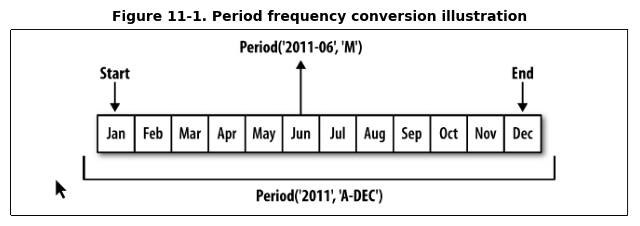

In [18]:
show_rounded_image(
    "images/fig11.1.jpg",
    radius=3,
    title="Figure 11-1. Period frequency conversion illustration",
    shadow=True
)

In [20]:
p = pd.Period('2007', freq='Y-JUN')

In [21]:
p

Period('2007', 'Y-JUN')

In [22]:
p.asfreq('M', 'start')

Period('2006-07', 'M')

In [23]:
p.asfreq('M', 'end')

Period('2007-06', 'M')

When you are converting from high to low frequency, pandas determines the superperiod
depending on where the subperiod “belongs.” For example, in `Y-JUN` frequency,
the month Aug-2007 is actually part of the 2008 period:

In [25]:
p = pd.Period('Aug-2007', 'M')

In [26]:
p.asfreq('Y-JUN')

Period('2008', 'Y-JUN')

Whole `PeriodIndex` objects or time series can be similarly converted with the same
semantics:

In [28]:
rng = pd.period_range('2006', '2009', freq='Y-DEC')

In [29]:
rng

PeriodIndex(['2006', '2007', '2008', '2009'], dtype='period[Y-DEC]')

In [30]:
ts = pd.Series(np.random.randn(len(rng)), index=rng)

In [31]:
ts

2006   -0.547424
2007   -1.951204
2008   -0.547536
2009   -1.014172
Freq: Y-DEC, dtype: float64

In [32]:
ts.asfreq('M', how='start')

2006-01   -0.547424
2007-01   -1.951204
2008-01   -0.547536
2009-01   -1.014172
Freq: M, dtype: float64

In [33]:
ts.asfreq('M', how='end')

2006-12   -0.547424
2007-12   -1.951204
2008-12   -0.547536
2009-12   -1.014172
Freq: M, dtype: float64

Here, the annual periods are replaced with monthly periods corresponding to the first/last
month falling within each annual period. If we instead wanted the last business day of
each year, we can use the `'B'` frequency and indicate that we want the end of the
period:

In [34]:
ts.asfreq('B', how='end')

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\3401117408.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  ts.asfreq('B', how='end')


2006-12-29   -0.547424
2007-12-31   -1.951204
2008-12-31   -0.547536
2009-12-31   -1.014172
Freq: B, dtype: float64

#### Quarterly Period Frequencies

Quarterly data is standard in accounting, finance, and other fields. Much quarterly
data is reported relative to a fiscal year end, typically the last calendar or business day
of one of the 12 months of the year. Thus, the period `2012Q4` has a different meaning
depending on fiscal year end. pandas supports all 12 possible quarterly frequencies as
`Q-JAN` through `Q-DEC`:

In [35]:
p = pd.Period('2012Q4', freq='Q-JAN')

In [36]:
p

Period('2012Q4', 'Q-JAN')

In the case of fiscal year ending in January, 2012Q4 runs from November through January,
which you can check by converting to daily frequency. See Figure 11-2 for an
illustration.

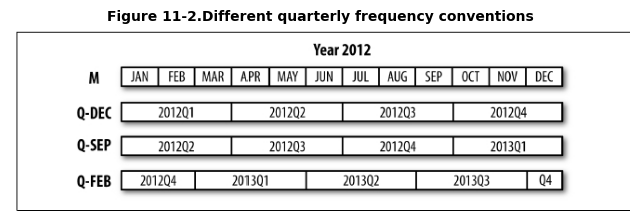

In [41]:
show_rounded_image(
    "images/fig11.2.jpg",
    radius=0,
    title="Figure 11-2.Different quarterly frequency conventions",
    shadow=True
)

Taking above example : 

In [42]:
p.asfreq('D', 'start')

Period('2011-11-01', 'D')

In [43]:
p.asfreq('D', 'end')

Period('2012-01-31', 'D')

Thus, it’s possible to do easy period arithmetic; for example, to get the timestamp at 4
PM on the second-to-last business day of the quarter, you could do:

In [45]:
p4pm = (p.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\180315518.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60
C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\180315518.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p4pm = (p.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60


In [46]:
p4pm

Period('2012-01-30 16:00', 'min')

In [47]:
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation</summary>

Let’s break this line **very slowly and conceptually** — this is a classic **time-series frequency conversion + timestamp construction pattern in Pandas.**

```python
p = pd.Period('2012Q4', freq='Q-JAN')
p4pm = (p.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60
```

This type of code is commonly used in **financial time-series / scheduling / market-close calculations**. 

---

#### ✅ Step 1 — Creating the Period

```python
p = pd.Period('2012Q4', freq='Q-JAN')
```

#### What this means

* `'2012Q4'` → 4th quarter of fiscal year
* `freq='Q-JAN'` →

This is VERY important.

👉 **Quarter ends in January (Fiscal year ends Jan).**

So quarters are:

| Quarter | Months  |
| ------- | ------- |
| Q1      | Feb–Apr |
| Q2      | May–Jul |
| Q3      | Aug–Oct |
| Q4      | Nov–Jan |

Thus:

✅ **`2012Q4` = Nov 2012 → Jan 2013**

So:

```
p represents the time span:
2012-11-01 → 2013-01-31
```

---

#### ✅ Step 2 — Convert Period to Business Day (End)

```python
p.asfreq('B', 'e')
```

Meaning:

* Convert quarter → **Business Day frequency**
* `'e'` → take **END of period**

So we get:

👉 **Last business day of Jan 2013**

Example:

If Jan 31 is weekday → Jan 31
If weekend → Jan 30 or Jan 29

Result is still a **Period object (Business Day period).**

---

#### ✅ Step 3 — Subtract 1

```python
(p.asfreq('B', 'e') - 1)
```

This means:

👉 Move **one business day backward**

So now we have:

> **Second last business day of the quarter**

This is VERY common in trading / reporting logic.

---

#### ✅ Step 4 — Convert to Minute Frequency (Start)

```python
.asfreq('T', 's')
```

Now we change frequency again:

* `'T'` → minute frequency
* `'s'` → **start of that business day**

So now we are at:

```
00:00 (midnight) of the second last business day
```

Still a Period.

---

#### ✅ Step 5 — Add 16 × 60 Minutes

```python
+ 16 * 60
```

Because:

```
16 * 60 = 960 minutes
```

So we move forward:

```
00:00 + 960 minutes = 16:00 (4 PM)
```

---

## 🎯 Final Meaning of Entire Expression

👉 **“Give me 4 PM on the second-last business day of fiscal quarter 2012Q4 (Jan-ending fiscal year)”**

This is a **precise timestamp construction trick.**

---

#### ✅ Why this Pattern is Powerful (Architect View)

This shows:

#### ⭐ Multi-level frequency navigation

We moved:

```
Quarter → Business Day → Minute → Specific Clock Time
```

This is:

> A VERY important Pandas time-series capability.

You can construct:

* market close timestamps
* reporting cutoffs
* billing deadlines
* rebalancing schedules

VERY cleanly.

---

#### ✅ If You Print Intermediate Values

You will see the story clearly:

```python
print(p)

print(p.asfreq('B', 'e'))

print(p.asfreq('B', 'e') - 1)

print((p.asfreq('B', 'e') - 1).asfreq('T', 's'))

print(p4pm)
```

---

#### 🚀 SUPER IMPORTANT Concept You Should Take Away

👉 **Period arithmetic happens in the unit of the current frequency**

So:

* subtract 1 from BusinessDay → subtract 1 business day
* add 960 in Minute freq → add 960 minutes

This is NOT datetime arithmetic —
this is **frequency-aware calendar arithmetic.**

---


Future proof Version :

In [48]:
p = pd.Period('2012Q4', freq='Q-JAN')

p4pm = (
    p.end_time
    .normalize()
    - pd.offsets.BDay(1)
    + pd.offsets.Hour(16)
)

p4pm

Timestamp('2012-01-30 16:00:00')

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation</summary>
##### ✅ Why You Are Getting These Warnings



There are **TWO separate deprecations** happening.

---

#### ⚠️ Warning 1

```
Period with BDay freq is deprecated
Use DatetimeIndex with BDay freq instead
```

### ✅ Meaning

Pandas team is **moving away from this pattern:**

```
Period → BusinessDay Period arithmetic
```

Why?

Because:

* Business days depend on **calendar logic**
* Period is meant for **fixed-span intervals**
* Business day is a **calendar-aware concept**

So Pandas wants you to use:

> 👉 **Timestamp / DatetimeIndex for business day operations**

Architecturally this is correct.

---

## ⚠️ Warning 2

```
'T' is deprecated → use 'min'
```

This is simple.

Old alias:

```
T = minute
```

New standard:

```
min = minute
```

---

# ✅ Future-Proof Version (Recommended)

We rewrite the logic using **Timestamp + offsets**

Goal still same:

> 👉 4 PM on second last business day of fiscal quarter

---

## ⭐ Clean Modern Version

```python
import pandas as pd

p = pd.Period('2012Q4', freq='Q-JAN')

# end of quarter as timestamp
q_end = p.end_time.normalize()

# second last business day
second_last_bd = q_end - pd.offsets.BDay(1)

# set time to 4 PM
p4pm = second_last_bd + pd.Timedelta(hours=16)

p4pm
```

---

## ✅ Why This is Future Safe

### ✔ No Period with BDay frequency

We only use:

```
Timestamp + BDay offset
```

This is Pandas-approved design direction.

---

### ✔ No 'T' alias

We use:

```
Timedelta(hours=16)
```

or could use:

```
Timedelta(minutes=960)
```

Both modern.

---

## 🎯 EVEN BETTER Architect Version

If you want **VERY expressive production code**

```python
p = pd.Period('2012Q4', freq='Q-JAN')

p4pm = (
    p.end_time
    .normalize()
    - pd.offsets.BDay(1)
    + pd.offsets.Hour(16)
)
```

This reads like English:

> end of quarter → go back 1 business day → add 16 hours

VERY maintainable.

---

# 🚀 Senior Insight (VERY IMPORTANT)

This warning is signaling a **bigger Pandas philosophy shift**

### OLD Pandas style (book style)

```
Use Period everywhere for calendar logic
```

### NEW Pandas direction

```
Use Period → only for labeling spans
Use Timestamp → for real calendar movement
Use offsets → for business / holiday logic
```

If you adopt this mental model:

👉 your time-series code will remain stable for years.

---



You can generate quarterly ranges using `period_range`. Arithmetic is identical, too:

In [49]:
rng = pd.period_range('2011Q3', '2012Q4', freq='Q-JAN')

In [50]:
rng

PeriodIndex(['2011Q3', '2011Q4', '2012Q1', '2012Q2', '2012Q3', '2012Q4'], dtype='period[Q-JAN]')

In [51]:
ts = pd.Series(np.arange(len(rng)), index=rng)

In [52]:
ts

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int64

In [53]:
new_rng = (rng.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\553239697.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_rng = (rng.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60
C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\553239697.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  new_rng = (rng.asfreq('B', 'e') - 1).asfreq('T', 's') + 16 * 60


In [54]:
ts.index = new_rng.to_timestamp()

In [55]:
ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

### Converting Timestamps to Periods (and Back)

Series and DataFrame objects indexed by timestamps can be converted to periods
with the `to_period` method:

In [57]:
rng = pd.date_range('2000-01-01', periods=3, freq='ME')

In [58]:
ts = pd.Series(np.random.randn(3), index=rng)

In [59]:
ts

2000-01-31   -0.526716
2000-02-29   -2.808202
2000-03-31   -0.279399
Freq: ME, dtype: float64

In [60]:
pts = ts.to_period()

In [61]:
pts

2000-01   -0.526716
2000-02   -2.808202
2000-03   -0.279399
Freq: M, dtype: float64

Since periods refer to non-overlapping timespans, a timestamp can only belong to a
single period for a given frequency. While the frequency of the new `PeriodIndex` is
inferred from the timestamps by default, you can specify any frequency you want.
There is also no problem with having duplicate periods in the result:

In [63]:
rng = pd.date_range('1/29/2000', periods=6, freq='D')

In [64]:
ts2 = pd.Series(np.random.randn(6), index=rng)

In [65]:
ts2.index

DatetimeIndex(['2000-01-29', '2000-01-30', '2000-01-31', '2000-02-01',
               '2000-02-02', '2000-02-03'],
              dtype='datetime64[ns]', freq='D')

In [67]:
ts3=ts2.to_period('M')

In [68]:
ts3.index

PeriodIndex(['2000-01', '2000-01', '2000-01', '2000-02', '2000-02', '2000-02'], dtype='period[M]')

To convert back to timestamps, use `to_timestamp`:

In [71]:
pts = ts3.to_timestamp(how='end')

In [72]:
pts

2000-01-31 23:59:59.999999999   -0.959511
2000-01-31 23:59:59.999999999   -0.121568
2000-01-31 23:59:59.999999999   -0.505859
2000-02-29 23:59:59.999999999    0.119778
2000-02-29 23:59:59.999999999    0.056797
2000-02-29 23:59:59.999999999   -0.359386
dtype: float64

In [74]:
pts.index

DatetimeIndex(['2000-01-31 23:59:59.999999999',
               '2000-01-31 23:59:59.999999999',
               '2000-01-31 23:59:59.999999999',
               '2000-02-29 23:59:59.999999999',
               '2000-02-29 23:59:59.999999999',
               '2000-02-29 23:59:59.999999999'],
              dtype='datetime64[ns]', freq=None)

### Creating a PeriodIndex from Arrays

Fixed frequency datasets are sometimes stored with timespan information spread
across multiple columns. For example, in this macroeconomic dataset, the year and
quarter are in different columns:

In [78]:
data = pd.read_csv('examples/macrodata.csv')

In [79]:
data.head(5)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [80]:
data.year

0      1959
1      1959
2      1959
3      1959
4      1960
       ... 
198    2008
199    2008
200    2009
201    2009
202    2009
Name: year, Length: 203, dtype: int64

In [81]:
data.quarter

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

By passing these arrays to `PeriodIndex` with a frequency, you can combine them to
form an index for the DataFrame:

In [82]:
index = pd.PeriodIndex(year=data.year, quarter=data.quarter,freq='Q-DEC')

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\3603458608.py:1: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  index = pd.PeriodIndex(year=data.year, quarter=data.quarter,freq='Q-DEC')


In [83]:
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [84]:
data.index = index

In [85]:
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959Q1,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1959Q2,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
1959Q3,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
1959Q4,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
1960Q1,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008Q3,2008,3,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
2008Q4,2008,4,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
2009Q1,2009,1,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
2009Q2,2009,2,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [86]:
index = pd.PeriodIndex.from_fields(
            year=data.year,
            quarter=data.quarter,
            freq='Q-DEC'
        )

In [87]:
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [88]:
data.index = index

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation</summary>
##### ✅ Why you are getting this **FutureWarning**

In recent **pandas versions**, constructing a `PeriodIndex` directly like this:

```python
pd.PeriodIndex(year=data.year, quarter=data.quarter, freq='Q-DEC')
```

has been **deprecated**.

Pandas is moving towards a **clearer and more explicit construction API**.

That is why you see:

> *FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.*

---

##### ✅ Correct (Modern) Way — Use `from_fields`

You should now write:

```python
index = pd.PeriodIndex.from_fields(
            year=data.year,
            quarter=data.quarter,
            freq='Q-DEC'
        )
```

✔ This will remove the warning
✔ This is forward-compatible with future pandas versions

---

##### 🧠 Senior Architect Insight — Why Pandas Changed This

Earlier:

* `PeriodIndex()` constructor was doing **too many implicit things**
* pandas is now redesigning constructors to be:

  * explicit
  * predictable
  * consistent across Index types

You will notice similar trends:

| Old Style                              | New Style                   |
| -------------------------------------- | --------------------------- |
| `PeriodIndex(year=..., month=...)`     | `PeriodIndex.from_fields()` |
| `DatetimeIndex([...])`                 | `pd.to_datetime()`          |
| timezone assignment inside constructor | `tz_localize()`             |

This is part of a **larger API cleanup**.

---

##### 🔥 Even Better Architectural Pattern (Very Important)

If your data is fundamentally **timestamp based**, then creating PeriodIndex from fields is often **not the best modeling choice**.

A stronger pattern is:

```python
dt = pd.to_datetime(
        dict(year=data.year, month=(data.quarter-1)*3 + 1, day=1)
)

index = dt.to_period('Q-DEC')
```

This gives you:

✅ cleaner pipeline
✅ easier debugging
✅ compatibility with plotting / resampling / time-zone operations
✅ avoids deprecated APIs
✅ aligns with pandas internal direction

---

##### 📌 Rule of Thumb (Data Science Architecture Level)

Use **PeriodIndex directly only when:**

* your data is *purely period semantic*
* like → accounting quarter labels, fiscal buckets

Use **DatetimeIndex → then convert to Period**

* when data comes from real time / transactions / events / logs
* this is **90% real-world case**

---



In [90]:
star_separator()

## 11.6 Resampling and Frequency Conversion
<hr class="reddot">

***Resampling*** refers to the process of converting a time series from one frequency to
another. Aggregating higher frequency data to lower frequency is called ***downsampling***,
while converting lower frequency to higher frequency is called ***upsampling***. Not
all resampling falls into either of these categories; for example, converting `W-WED`
(weekly on Wednesday) to `W-FRI` is neither upsampling nor downsampling.

pandas objects are equipped with a `resample` method, which is the workhorse function
for all frequency conversion. `resample` has a similar API to groupby; you call
`resample` to group the data, then call an aggregation function:

In [144]:
rng = pd.date_range('2000-01-01', periods=100, freq='D')

In [145]:
ts = pd.Series(np.random.randn(len(rng)), index=rng)

In [146]:
ts

2000-01-01   -1.274486
2000-01-02   -0.813020
2000-01-03    0.094899
2000-01-04    1.334149
2000-01-05   -1.749568
                ...   
2000-04-05    0.896946
2000-04-06    0.046767
2000-04-07   -1.958903
2000-04-08    1.029303
2000-04-09   -0.165615
Freq: D, Length: 100, dtype: float64

In [151]:
ts.loc('2000-01-31')

ValueError: No axis named 2000-01-31 for object type Series

In [148]:
ts.resample('ME').mean()

2000-01-31   -0.292498
2000-02-29    0.278022
2000-03-31    0.344605
2000-04-30   -0.409260
Freq: ME, dtype: float64

In [155]:
print(ts.loc[['2000-01-31', '2000-02-29', '2000-03-31']])

2000-01-31    0.190716
2000-02-29    1.192616
2000-03-31    2.943980
dtype: float64


In [156]:
ts.resample('M', kind='period').mean()

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\1597458493.py:1: FutureWarning: The 'kind' keyword in Series.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  ts.resample('M', kind='period').mean()
C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_42656\1597458493.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.resample('M', kind='period').mean()


2000-01   -0.292498
2000-02    0.278022
2000-03    0.344605
2000-04   -0.409260
Freq: M, dtype: float64


<details class="collapsible blue-box">
<summary>📘 Click to expand explanation</summary>
##### ✅ What does `ts.resample('M', kind='period').mean()` do ?

This is a **time-series frequency conversion + aggregation operation** in Pandas.

Let’s break it **like a senior data science architect 🙂**

---

##### 🔹 Step 1 — `ts.resample('M', ...)`

`resample()` means:

> **“Group the time series into new time buckets based on a new frequency.”**

Here:

```
'M'  → Month End frequency
```

So Pandas will:

👉 Take your time series `ts`
👉 Create **monthly groups (bins)**
👉 Then you can apply an aggregation like `.mean()`

Example mental model:

| Date   | Value |
| ------ | ----- |
| Jan 3  | 10    |
| Jan 20 | 20    |
| Feb 5  | 30    |

After resampling monthly → groups become:

* January group → [10, 20]
* February group → [30]

---

##### 🔹 Step 2 — `kind='period'`

This is **VERY important and often misunderstood.**

Normally:

```
resample → returns DatetimeIndex
```

But when you write:

```
kind='period'
```

You are telling Pandas:

> ❗ “Return the result indexed by **PeriodIndex** instead of DatetimeIndex.”

So output index becomes:

```
PeriodIndex(['2024-01', '2024-02'], freq='M')
```

instead of:

```
DatetimeIndex(['2024-01-31', '2024-02-29'])
```

---

##### 🔹 Step 3 — `.mean()`

After grouping into monthly buckets:

```
.mean()
```

computes:

> **Average value inside each month**

So full pipeline means:

✅ Group values month-wise
✅ Use PeriodIndex to represent months
✅ Compute mean per month

---

##### 🔥 Architect Level Insight (Very Important)

`resample()` is basically:

```
Time-based GROUP BY
```

So this is conceptually same as:

```
SQL → GROUP BY month(date)
```

But for time series.

---

##### 🧠 When should you use `kind='period'` ?

Use it when:

✅ You are doing **financial / accounting / quarterly / monthly analytics**

Because:

* PeriodIndex represents **time spans**
* DatetimeIndex represents **time instants**

Example:

| Good for Period | Good for Datetime |
| --------------- | ----------------- |
| Monthly sales   | Sensor readings   |
| Quarterly GDP   | Stock tick data   |
| Annual reports  | Logs              |

---

##### ⚠️ Modern Pandas Note

In newer Pandas workflows, people often instead do:

```
ts.to_period('M').groupby(...).mean()
```

because internally Pandas is moving more toward explicit period handling. 

---

##### ✅ Quick Visual Code Example

```python
import pandas as pd
import numpy as np

ts = pd.Series(
    np.random.randn(6),
    index=pd.date_range("2024-01-10", periods=6, freq="10D")
)

ts.resample('M', kind='period').mean()
```

Output:

```
2024-01    0.12
2024-02   -0.45
Freq: M
```

---



This gives deprecation warning : 
`FutureWarning: The 'kind' keyword in Series.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  ts.resample('M', kind='period').mean()`

In [158]:
ts.to_period('M').groupby(level=0).mean()

2000-01   -0.292498
2000-02    0.278022
2000-03    0.344605
2000-04   -0.409260
Freq: M, dtype: float64

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation</summary>

##### ✅ Why are you getting this `FutureWarning` ?

You are seeing:

```
FutureWarning: The 'kind' keyword in Series.resample is deprecated
```

This means:

> ❗ Pandas will **remove `kind='period'` from `resample()` in future versions**

So instead of asking `resample()` to convert the index type,
Pandas now wants you to **explicitly convert the index yourself first.**

This is part of a broader design cleanup in time-series APIs.

---

##### ✅ Correct Modern Way (Very Important)

Instead of:

```python
ts.resample('M', kind='period').mean()
```

You should now write:

```python
ts.to_period('M').groupby(level=0).mean()
```

---

##### 🔹 What is happening here ?

Step-by-step architect view:

### ✅ Step 1 — Convert index to PeriodIndex

```python
ts_p = ts.to_period('M')
```

Now index becomes:

```
PeriodIndex(['2024-01', '2024-01', '2024-02' ...])
```

Meaning:

👉 Each timestamp is now mapped to its **month period**

---

### ✅ Step 2 — Group by that period

```python
ts_p.groupby(level=0).mean()
```

Now Pandas:

* groups all rows belonging to same month
* calculates mean

This is **exactly equivalent to old resample behaviour.**

---

##### ⭐ Even Cleaner Pattern (Senior DS Pattern)

Very commonly used in production pipelines:

```python
ts.groupby(ts.index.to_period('M')).mean()
```

This avoids modifying the original series.

---

##### 🧠 Why Pandas is doing this change ?

Because earlier:

```
resample → was doing TWO jobs
```

1. frequency conversion
2. index type conversion

This was considered **API mixing responsibilities**

Now philosophy is:

> ✔ You control index type
> ✔ resample only does frequency grouping

Cleaner design → fewer hidden behaviours.

---

##### 🔥 Very Important Interview Insight

Understand these layers clearly:

| Operation     | Meaning                                |
| ------------- | -------------------------------------- |
| `asfreq()`    | just change frequency → NO aggregation |
| `resample()`  | change frequency + aggregation         |
| `to_period()` | change time representation             |
| `groupby()`   | generic aggregation engine             |

Modern Pandas prefers **composing small operations** instead of one magical API.

---

##### ✅ Final Recommended Replacement

If you want exact replacement of your code:

```python
ts.groupby(ts.index.to_period('M')).mean()
```

---



`resample` is a flexible and high-performance method that can be used to process very
large time series. The examples in the following sections illustrate its semantics and
use. Table 11-5 summarizes some of its options.

In [161]:
columns = ["Argument", "Description"]

rows = [
["freq","String or DateOffset indicating desired resampled frequency (e.g., 'M', '5min', Second(15))"],
["axis","Axis to resample on; default axis=0"],
["fill_method","Interpolation when upsampling such as 'ffill' or 'bfill'"],
["closed","Which interval end is inclusive during downsampling: 'right' or 'left'"],
["label","Whether result is labeled with right or left bin edge"],
["loffset","Time adjustment to bin labels (e.g., '-1s')"],
["limit","Maximum number of periods to fill during forward/backward fill"],
["kind","Aggregate to 'period' or 'timestamp'; defaults to index type"],
["convention","When resampling periods, whether conversion uses 'start' or 'end'"]
]

render_book_table(
    "Table 11-5. Resample Method Arguments",
    columns,
    rows
)

Argument,Description
freq,"String or DateOffset indicating desired resampled frequency (e.g., 'M', '5min', Second(15))"
axis,Axis to resample on; default axis=0
fill_method,Interpolation when upsampling such as 'ffill' or 'bfill'
closed,Which interval end is inclusive during downsampling: 'right' or 'left'
label,Whether result is labeled with right or left bin edge
loffset,"Time adjustment to bin labels (e.g., '-1s')"
limit,Maximum number of periods to fill during forward/backward fill
kind,Aggregate to 'period' or 'timestamp'; defaults to index type
convention,"When resampling periods, whether conversion uses 'start' or 'end'"


### Downsampling

Aggregating data to a regular, lower frequency is a pretty normal time series task. The
data you’re aggregating doesn’t need to be fixed frequently; the desired frequency
defines bin edges that are used to slice the time series into pieces to aggregate. For
example, to convert to monthly, `'M'` or `'BM'`, you need to chop up the data into onemonth
intervals. Each interval is said to be half-open; a data point can only belong to
one interval, and the union of the intervals must make up the whole time frame.
There are a couple things to think about when using `resample` to downsample data:

* Which side of each interval is closed
* How to label each aggregated bin, either with the start of the interval or the end

To illustrate, let’s look at some one-minute data:

In [164]:
rng = pd.date_range('2000-01-01', periods=12, freq='min')

In [165]:
ts = pd.Series(np.arange(12), index=rng)

In [166]:
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

Suppose you wanted to aggregate this data into five-minute chunks or bars by taking
the sum of each group:

In [170]:
ts.resample('5min', ).sum()

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

The frequency you pass defines bin edges in five-minute increments.

By default,
the left bin edge is inclusive, so the `00:00` value is included in the `00:00` to `00:05` interval. But `00:05` is not included. 

Passing `closed='right'` changes the interval to be closed on the right:

In [173]:
ts.resample('5min', closed='right').sum()

1999-12-31 23:55:00     0
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5min, dtype: int64

The resulting time series is labeled by the timestamps from the left side of each bin.
By passing `label='right'` you can label them with the right bin edge:

In [174]:
ts.resample('5min', closed='right', label='right').sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int64

In [175]:
ts.resample('5min', closed='left', label='right').sum()

2000-01-01 00:05:00    10
2000-01-01 00:10:00    35
2000-01-01 00:15:00    21
Freq: 5min, dtype: int64

See Figure 11-3 for an illustration of minute frequency data being resampled to fiveminute
frequency.

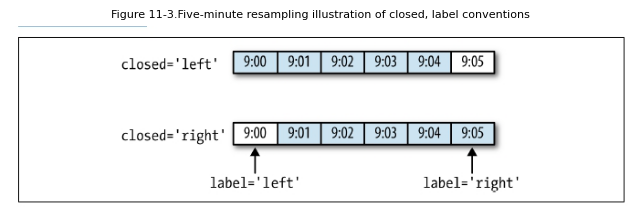

In [176]:
show_rounded_image(
    "images/fig11.3.jpg",
    radius=0,
    title="Figure 11-3.Five-minute resampling illustration of closed, label conventions",
    shadow=True
)

Lastly, you might want to shift the result index by some amount, say subtracting one
second from the right edge to make it more clear which interval the timestamp refers
to. To do this, pass a string or date offset to `loffset`:

In [179]:
ts.resample('5min', closed='right',label='right').sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int64

In [180]:
ts.resample('5min', closed='right',label='right', loffset='-1s').sum()

TypeError: NDFrame.resample() got an unexpected keyword argument 'loffset'. Did you mean 'offset'?

This is because the loffset parameter is already removed. Below code does the same in more future proof way. 

In [184]:
res = ts.resample(
        '5min',
        closed='right',
        label='right'
      ).sum()
res.index = res.index - pd.Timedelta('1s')

In [182]:
res

1999-12-31 23:59:59     0
2000-01-01 00:04:59    15
2000-01-01 00:09:59    40
2000-01-01 00:14:59    11
Freq: 5min, dtype: int64

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation</summary>

##### ✅ Why you are getting this error

```text
TypeError: NDFrame.resample() got an unexpected keyword argument 'loffset'.
Did you mean 'offset'?
```

This happens because:

👉 **`loffset` has been removed (deprecated earlier → now fully removed in newer pandas).**

So modern pandas versions **do NOT support `loffset` anymore.**

---

##### 🧠 What `loffset` used to do (Old Pandas)

It was used to:

> shift the **result index labels AFTER resampling**

Example old usage:

```python
ts.resample('5min', loffset='-1s').sum()
```

Meaning:

* create normal 5-minute bins
* then move the **final timestamps backward by 1 second**

---

##### ✅ Modern Correct Way (Architect-Level Fix)

You now do this in **two clean steps**

### ⭐ Option 1 — use `offset` (shift bin boundaries)

```python
ts.resample(
    '5min',
    closed='right',
    label='right',
    offset='-1s'
).sum()
```

This shifts the **window construction itself**

---

### ⭐ Option 2 — shift index AFTER resampling (Best replacement for loffset)

This is the **true semantic replacement**

```python
res = ts.resample(
        '5min',
        closed='right',
        label='right'
      ).sum()

res.index = res.index - pd.Timedelta('1s')
```

✅ This exactly replicates old `loffset`

Very important distinction:

| Parameter     | What it shifts               |
| ------------- | ---------------------------- |
| `offset`      | shifts **bin boundaries**    |
| old `loffset` | shifts **final labels only** |

This is a **VERY exam / interview favourite trap**

---

##### 🎯 Senior Data Engineering Insight

Modern pandas philosophy:

> ❗ Resample should ONLY define grouping
> ❗ Index manipulation should be explicit

This improves:

* pipeline clarity
* debugging
* reproducibility in analytics workflows

---

##### ⭐ Clean Production Pattern

You will often see:

```python
agg = (
    ts
    .resample('5min', closed='right', label='right')
    .sum()
    .rename_axis('time_bucket')
)

agg.index = agg.index - pd.Timedelta(seconds=1)
```

Very readable ✔
Very maintainable ✔
Very scalable ✔

---

If you want, next I can explain something **VERY powerful**:

👉 Difference between
**`offset` vs `origin` vs `base` vs anchor alignment**

Once you understand that — time series resampling becomes *fully deterministic in your mind*.


There is another parameter called offset, which shifts  the index bfore grouping. data result looks entirely different with it

In [183]:
ts.resample('5min', closed='right',label='right', offset='-1s').sum()

2000-01-01 00:04:59    10
2000-01-01 00:09:59    35
2000-01-01 00:14:59    21
Freq: 5min, dtype: int64

<details class="collapsible blue-box">
<summary>📘 Click to expand explanation</summary>
##### ✅ Why data looks different with "iffset" ? 
Short Answer

Because:

> ⭐ **`offset='-1s'` shifts the bucket boundaries BEFORE grouping**
> ⭐ **manual index shift (old loffset style) shifts labels AFTER grouping**

So the **data that goes into each bucket becomes different.**

This is why:

* number of rows changes
* totals change

Very important conceptual distinction.

---

##### ✅ Let’s Understand Using Your Exact Data

You created:

```python
rng = pd.date_range('2000-01-01', periods=12, freq='min')
ts = pd.Series(np.arange(12), index=rng)
```

So data is:

| Time  | Value |
| ----- | ----- |
| 00:00 | 0     |
| 00:01 | 1     |
| 00:02 | 2     |
| 00:03 | 3     |
| 00:04 | 4     |
| 00:05 | 5     |
| 00:06 | 6     |
| 00:07 | 7     |
| 00:08 | 8     |
| 00:09 | 9     |
| 00:10 | 10    |
| 00:11 | 11    |

---

##### ✅ Case-1 → Normal resample + shift index later

```python
res = ts.resample('5min', closed='right', label='right').sum()
res.index = res.index - pd.Timedelta('1s')
```

Here pandas FIRST builds buckets like:

```
(-00:05 , 00:00]  → contains 00:00 → sum = 0  
(00:00 , 00:05]   → contains 1,2,3,4,5 → sum = 15  
(00:05 , 00:10]   → contains 6,7,8,9,10 → sum = 40  
(00:10 , 00:15]   → contains 11 → sum = 11
```

Then you ONLY shift labels:

```
00:00 → 23:59:59  
00:05 → 00:04:59  
00:10 → 00:09:59  
00:15 → 00:14:59
```

👉 **Grouping did NOT change.
Only timestamps printed changed.**

So totals remain:

```
0, 15, 40, 11
```

---

##### ✅ Case-2 → Using `offset='-1s'`

```python
ts.resample('5min', closed='right', label='right', offset='-1s').sum()
```

Now pandas shifts bucket grid FIRST.

So buckets become:

```
(23:59:59 , 00:04:59] → contains 00:00–00:04 → sum = 10  
(00:04:59 , 00:09:59] → contains 00:05–00:09 → sum = 35  
(00:09:59 , 00:14:59] → contains 00:10–00:11 → sum = 21
```

👉 Notice:

* value `0` is no longer alone in its own bucket
* value `5` moved to next bucket
* bucket structure completely changed

Hence totals:

```
10, 35, 21
```

Also number of rows becomes **3 instead of 4**

Because the shifted grid no longer creates a tiny first bucket.

---

##### ⭐ Architect Level Mental Model

Think of resample like:

```
STEP-1 → draw time grid  
STEP-2 → drop data into grid  
STEP-3 → compute aggregation  
STEP-4 → print labels
```

Now:

| Method             | Which step changes     |
| ------------------ | ---------------------- |
| Manual index shift | Step-4 only            |
| `offset`           | Step-1 (very powerful) |

Since **grid itself changes → grouping changes → totals change**

---

##### ⭐ Golden Rule (Remember Forever)

> ❗ `offset` changes **which data belongs to which bucket**
> ❗ `loffset-style index shift` changes **only bucket naming**

This is why results differ.

---



In [185]:
rng = pd.date_range('2000-01-01 23:57:00', periods=12, freq='min')

In [186]:
ts = pd.Series(np.arange(12), index=rng)

In [187]:
ts

2000-01-01 23:57:00     0
2000-01-01 23:58:00     1
2000-01-01 23:59:00     2
2000-01-02 00:00:00     3
2000-01-02 00:01:00     4
2000-01-02 00:02:00     5
2000-01-02 00:03:00     6
2000-01-02 00:04:00     7
2000-01-02 00:05:00     8
2000-01-02 00:06:00     9
2000-01-02 00:07:00    10
2000-01-02 00:08:00    11
Freq: min, dtype: int64

In [188]:
res = ts.resample( '5min', closed='right', label='right' ).sum()

In [189]:
res

2000-01-02 00:00:00     6
2000-01-02 00:05:00    30
2000-01-02 00:10:00    30
Freq: 5min, dtype: int64

So 5 min Buckts starts from nearest 00?

In [190]:
rng = pd.date_range('2000-01-01 23:51:00', periods=12, freq='min')

In [191]:
ts = pd.Series(np.arange(12), index=rng)

In [192]:
ts

2000-01-01 23:51:00     0
2000-01-01 23:52:00     1
2000-01-01 23:53:00     2
2000-01-01 23:54:00     3
2000-01-01 23:55:00     4
2000-01-01 23:56:00     5
2000-01-01 23:57:00     6
2000-01-01 23:58:00     7
2000-01-01 23:59:00     8
2000-01-02 00:00:00     9
2000-01-02 00:01:00    10
2000-01-02 00:02:00    11
Freq: min, dtype: int64

In [193]:
ts.resample( '5min', closed='right', label='right' ).sum()

2000-01-01 23:55:00    10
2000-01-02 00:00:00    35
2000-01-02 00:05:00    21
Freq: 5min, dtype: int64

<Div class="green-box">
So 5 min Buckets starts from nearest 5 min division.



You also could have accomplished the effect of loffset by calling the shift method
on the result without the loffset.

#### Open-High-Low-Close (OHLC) resampling

In finance, a popular way to aggregate a time series is to compute four values for each
bucket: the first (open), last (close), maximum (high), and minimal (low) values. By
using the `ohlc` aggregate function you will obtain a DataFrame having columns containing
these four aggregates, which are efficiently computed in a single sweep of the
data:

In [195]:
ts.resample('5min').ohlc()

,open,high,low,close
2000-01-01 23:50:00,0,3,0,3
2000-01-01 23:55:00,4,8,4,8
2000-01-02 00:00:00,9,11,9,11


### Upsampling and Interpolation

When converting from a low frequency to a higher frequency, no aggregation is
needed. Let’s consider a DataFrame with some weekly data:

In [198]:
frame = pd.DataFrame(np.random.randn(2, 4),
                     index=pd.date_range('1/1/2000', periods=2,freq='W-WED'),
                     columns=['Colorado', 'Texas', 'New York', 'Ohio'])

In [199]:
frame

,Colorado,Texas,New York,Ohio
2000-01-05,0.174617,-0.120768,-0.407000,0.731183
2000-01-12,0.918908,1.052504,-0.501753,0.626731


When you are using an aggregation function with this data, there is only one value
per group, and missing values result in the gaps. We use the `asfreq` method to convert
to the higher frequency without any aggregation:

In [200]:
df_daily = frame.resample('D').asfreq()

In [201]:
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,0.174617,-0.120768,-0.407000,0.731183
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.918908,1.052504,-0.501753,0.626731


Suppose you wanted to fill forward each weekly value omn the non-Wednesdays. The
same filling or interpolation methods available in the `fillna` and `reindex` methods
are available for resampling:

In [204]:
frame.resample('D').ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,0.174617,-0.120768,-0.407000,0.731183
2000-01-06,0.174617,-0.120768,-0.407000,0.731183
2000-01-07,0.174617,-0.120768,-0.407000,0.731183
2000-01-08,0.174617,-0.120768,-0.407000,0.731183
2000-01-09,0.174617,-0.120768,-0.407000,0.731183
2000-01-10,0.174617,-0.120768,-0.407000,0.731183
2000-01-11,0.174617,-0.120768,-0.407000,0.731183
2000-01-12,0.918908,1.052504,-0.501753,0.626731


You can similarly choose to only fill a certain number of periods forward to limit how
far to continue using an observed value:

In [205]:
frame.resample('D').ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,0.174617,-0.120768,-0.407000,0.731183
2000-01-06,0.174617,-0.120768,-0.407000,0.731183
2000-01-07,0.174617,-0.120768,-0.407000,0.731183
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.918908,1.052504,-0.501753,0.626731


Backward fill also.

In [207]:
frame.resample('D').bfill()

,Colorado,Texas,New York,Ohio
2000-01-05,0.174617,-0.120768,-0.407000,0.731183
2000-01-06,0.918908,1.052504,-0.501753,0.626731
2000-01-07,0.918908,1.052504,-0.501753,0.626731
2000-01-08,0.918908,1.052504,-0.501753,0.626731
2000-01-09,0.918908,1.052504,-0.501753,0.626731
2000-01-10,0.918908,1.052504,-0.501753,0.626731
2000-01-11,0.918908,1.052504,-0.501753,0.626731
2000-01-12,0.918908,1.052504,-0.501753,0.626731


Notably, the new date index need not overlap with the old one at all:

In [209]:
frame

,Colorado,Texas,New York,Ohio
2000-01-05,0.174617,-0.120768,-0.407000,0.731183
2000-01-12,0.918908,1.052504,-0.501753,0.626731


In [210]:
frame.resample('W-THU').ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,0.174617,-0.120768,-0.407000,0.731183
2000-01-13,0.918908,1.052504,-0.501753,0.626731


In [211]:
frame.resample('W-TUE').ffill()

,Colorado,Texas,New York,Ohio
2000-01-11,0.174617,-0.120768,-0.407000,0.731183
2000-01-18,0.918908,1.052504,-0.501753,0.626731


In [212]:
frame.index

DatetimeIndex(['2000-01-05', '2000-01-12'], dtype='datetime64[ns]', freq='W-WED')

### Resampling with Periods

Resampling data indexed by periods is similar to timestamps:

In [213]:
frame = pd.DataFrame(np.random.randn(24, 4),
                     index=pd.period_range('1-2000', '12-2001',freq='M'),
                     columns=['Colorado', 'Texas', 'New York', 'Ohio'])

In [214]:
frame

,Colorado,Texas,New York,Ohio
2000-01,-1.467670,1.381071,-0.171289,-0.223005
2000-02,0.599486,-1.381081,1.676192,0.078302
2000-03,0.662156,3.079590,-0.991448,-0.461594
2000-04,-1.275205,-0.386015,-0.656982,-0.927961
2000-05,-0.754779,-0.247893,-1.444965,-0.474485
2000-06,-0.239810,1.523290,0.661375,0.846821
2000-07,-1.125747,-0.215927,0.461204,0.721477
2000-08,-2.774619,0.103850,-1.145336,-0.681141
2000-09,-0.001628,0.623006,1.079951,-0.975044
2000-10,0.205659,1.661234,0.197572,0.378363


In [215]:
annual_frame = frame.resample('Y-DEC').mean()

In [216]:
annual_frame

,Colorado,Texas,New York,Ohio
2000,-0.706951,0.495869,0.004830,-0.217599
2001,0.007179,-0.422647,0.323807,0.116236


Upsampling is more nuanced, as you must make a decision about which end of the
timespan in the new frequency to place the values before resampling, just like the
`asfreq` method. The `convention` argument defaults to `'start'` but can also be `'end'`:

In [217]:
annual_frame.resample('Q-DEC').ffill()

,Colorado,Texas,New York,Ohio
2000Q1,-0.706951,0.495869,0.004830,-0.217599
2000Q2,-0.706951,0.495869,0.004830,-0.217599
2000Q3,-0.706951,0.495869,0.004830,-0.217599
2000Q4,-0.706951,0.495869,0.004830,-0.217599
2001Q1,0.007179,-0.422647,0.323807,0.116236
2001Q2,0.007179,-0.422647,0.323807,0.116236
2001Q3,0.007179,-0.422647,0.323807,0.116236
2001Q4,0.007179,-0.422647,0.323807,0.116236


In [218]:
annual_frame.resample('Q-DEC', convention='end').ffill()

,Colorado,Texas,New York,Ohio
2000Q4,-0.706951,0.495869,0.004830,-0.217599
2001Q1,-0.706951,0.495869,0.004830,-0.217599
2001Q2,-0.706951,0.495869,0.004830,-0.217599
2001Q3,-0.706951,0.495869,0.004830,-0.217599
2001Q4,0.007179,-0.422647,0.323807,0.116236


Since periods refer to timespans, the rules about upsampling and downsampling are
more rigid:

* In downsampling, the target frequency must be a subperiod of the source
frequency.
* In upsampling, the target frequency must be a superperiod of the source
frequency.

If these rules are not satisfied, an exception will be raised. This mainly affects the
quarterly, annual, and weekly frequencies; for example, the timespans defined by `QMAR`
only line up with `Y-MAR`, `Y-JUN`, `Y-SEP` , and `Y-DEC` :



In [222]:
annual_frame.resample('Q-MAR').ffill()

,Colorado,Texas,New York,Ohio
2000Q4,-0.706951,0.495869,0.004830,-0.217599
2001Q1,-0.706951,0.495869,0.004830,-0.217599
2001Q2,-0.706951,0.495869,0.004830,-0.217599
2001Q3,-0.706951,0.495869,0.004830,-0.217599
2001Q4,0.007179,-0.422647,0.323807,0.116236
2002Q1,0.007179,-0.422647,0.323807,0.116236
2002Q2,0.007179,-0.422647,0.323807,0.116236
2002Q3,0.007179,-0.422647,0.323807,0.116236


In [223]:
star_separator()

## 11.7 Moving Window Functions

An important class of array transformations used for time series operations are statistics
and other functions evaluated over a sliding window or with exponentially decaying
weights. This can be useful for smoothing noisy or gappy data. I call these ***moving
window functions***, even though it includes functions without a fixed-length window like exponentially weighted moving average. Like other statistical functions, these
also automatically exclude missing data.

Before digging in, we can load up some time series data and resample it to business
day frequency:

In [226]:
close_px_all = pd.read_csv('examples/stock_px.csv',parse_dates=True, index_col=0)

In [227]:
close_px = close_px_all[['AAPL', 'MSFT', 'XOM']]

In [228]:
close_px 

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


In [229]:
close_px = close_px.resample('B').ffill()

In [230]:
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


I now introduce the rolling operator, which behaves similarly to `resample` and
groupby. It can be called on a Series or DataFrame along with a window (expressed as
a number of periods; see Figure 11-4 for the plot created):`

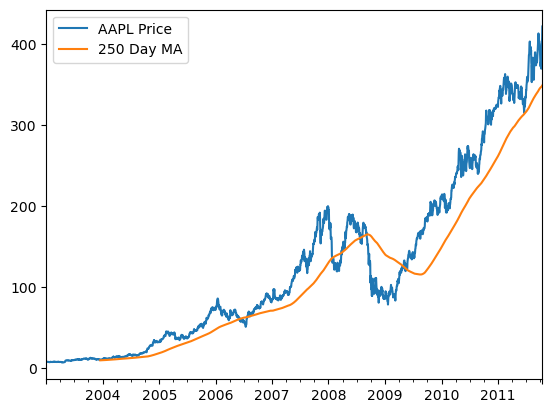

In [234]:
ax = close_px.AAPL.plot(label="AAPL Price")

close_px.AAPL.rolling(250).mean().plot(
    ax=ax,
    label="250 Day MA"
)

ax.legend()

The expression `rolling(250)` is similar in behavior to groupby, but instead of grouping
it creates an object that enables grouping over a 250-day sliding window. So here
we have the 250-day moving window average of Apple’s stock price.

By default rolling functions require all of the values in the window to be non-NA.
This behavior can be changed to account for missing data and, in particular, the fact
that you will have fewer than window periods of data at the beginning of the time
series

In [235]:
appl_std250 = close_px.AAPL.rolling(250, min_periods=10).std()

In [236]:
appl_std250

2003-01-02          NaN
2003-01-03          NaN
2003-01-06          NaN
2003-01-07          NaN
2003-01-08          NaN
                ...    
2011-10-10    25.430104
2011-10-11    25.523131
2011-10-12    25.624851
2011-10-13    25.758644
2011-10-14    25.993449
Freq: B, Name: AAPL, Length: 2292, dtype: float64

In [237]:
appl_std250 = close_px.AAPL.rolling(250, min_periods=15).std()

In [240]:
appl_std250.head(15)

2003-01-02         NaN
2003-01-03         NaN
2003-01-06         NaN
2003-01-07         NaN
2003-01-08         NaN
2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16         NaN
2003-01-17         NaN
2003-01-20         NaN
2003-01-21         NaN
2003-01-22    0.169008
Freq: B, Name: AAPL, dtype: float64

<Axes: >

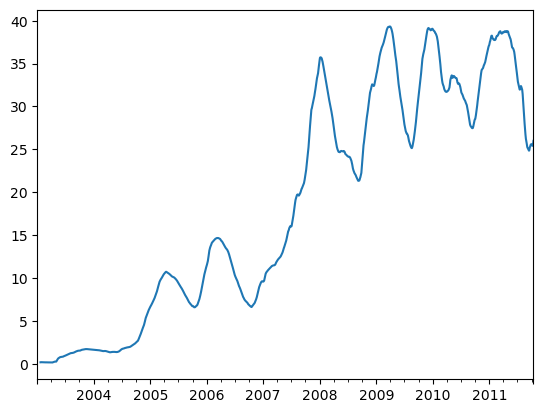

In [241]:
appl_std250.plot()

In order to compute an expanding window mean, use the `expanding` operator instead
of rolling. The expanding mean starts the time window from the beginning of the
time series and increases the size of the window until it encompasses the whole series.
An expanding window mean on the `apple_std250` time series looks like this:

In [242]:
expanding_mean = appl_std250.expanding().mean()

<Axes: >

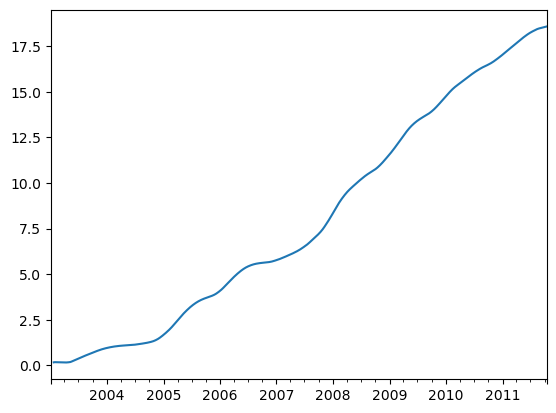

In [244]:
expanding_mean.plot()

Calling a moving window function on a DataFrame applies the transformation to
each column

<Axes: >

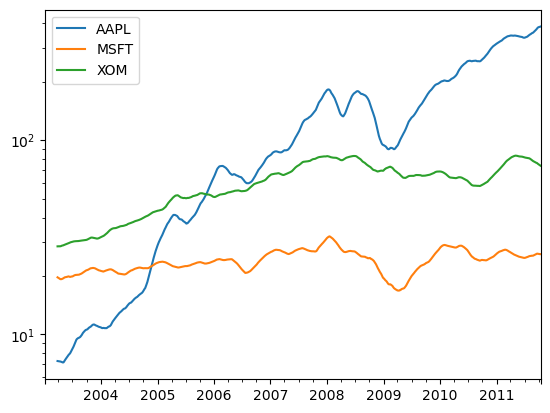

In [246]:
close_px.rolling(60).mean().plot(logy=True)

The `rolling` function also accepts a string indicating a fixed-size time offset rather
than a set number of periods. Using this notation can be useful for irregular time series.
These are the same strings that you can pass to `resample`. For example, we could
compute a 20-day rolling mean like so:

In [247]:
close_px.rolling('20D').mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


#### Exponentially Weighted Functions

An alternative to using a static window size with equally weighted observations is to
specify a constant ***decay factor*** to give more weight to more recent observations.
There are a couple of ways to specify the decay factor. A popular one is using a ***span***,
which makes the result comparable to a simple moving window function with window
size equal to the span.



Since an exponentially weighted statistic places more weight on more recent observations,
it “adapts” faster to changes compared with the equal-weighted version.

pandas has the `ewm` operator to go along with `rolling` and `expanding`. Here’s an
example comparing a 60-day moving average of Apple’s stock price with an EW moving
average with `span=60` 

In [248]:
aapl_px = close_px.AAPL['2006':'2007']

In [249]:
ma60 = aapl_px.rolling(30, min_periods=20).mean()

In [250]:
ewma60 = aapl_px.ewm(span=30).mean()

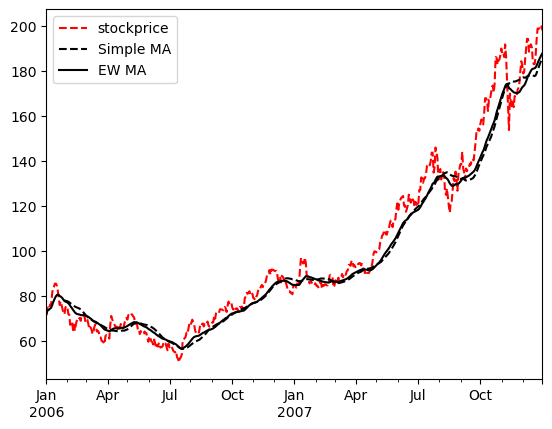

In [253]:
aapl_px.plot(style='r--', label='stockprice')
ma60.plot(style='k--', label='Simple MA')
ewma60.plot(style='k-', label='EW MA')
plt.legend()

### Binary Moving Window Functions

Some statistical operators, like correlation and covariance, need to operate on two
time series. As an example, financial analysts are often interested in a stock’s correlation
to a benchmark index like the S&P 500. To have a look at this, we first compute
the percent change for all of our time series of interest:

In [254]:
spx_px = close_px_all['SPX']

In [255]:
spx_px

2003-01-02     909.03
2003-01-03     908.59
2003-01-06     929.01
2003-01-07     922.93
2003-01-08     909.93
               ...   
2011-10-10    1194.89
2011-10-11    1195.54
2011-10-12    1207.25
2011-10-13    1203.66
2011-10-14    1224.58
Name: SPX, Length: 2214, dtype: float64

In [256]:
spx_rets = spx_px.pct_change()

In [257]:
spx_rets

2003-01-02         NaN
2003-01-03   -0.000484
2003-01-06    0.022474
2003-01-07   -0.006545
2003-01-08   -0.014086
                ...   
2011-10-10    0.034125
2011-10-11    0.000544
2011-10-12    0.009795
2011-10-13   -0.002974
2011-10-14    0.017380
Name: SPX, Length: 2214, dtype: float64

In [258]:
returns = close_px.pct_change()

In [259]:
returns

,AAPL,MSFT,XOM
2003-01-02,NaN,NaN,NaN
2003-01-03,0.006757,0.001421,0.000684
2003-01-06,0.000000,0.017975,0.024624
2003-01-07,-0.002685,0.019052,-0.033712
2003-01-08,-0.020188,-0.028272,-0.004145
...,...,...,...
2011-10-10,0.051406,0.026286,0.036977
2011-10-11,0.029526,0.002227,-0.000131
2011-10-12,0.004747,-0.001481,0.011669
2011-10-13,0.015515,0.008160,-0.010238


The `corr` aggregation function after we call rolling can then compute the rolling
correlation with `spx_rets` 

In [261]:
corr = returns.AAPL.rolling(125, min_periods=100).corr(spx_rets)

In [262]:
corr

2003-01-02         NaN
2003-01-03         NaN
2003-01-06         NaN
2003-01-07         NaN
2003-01-08         NaN
                ...   
2011-10-10    0.736464
2011-10-11    0.729906
2011-10-12    0.728404
2011-10-13    0.727165
2011-10-14    0.729858
Length: 2292, dtype: float64

<Axes: >

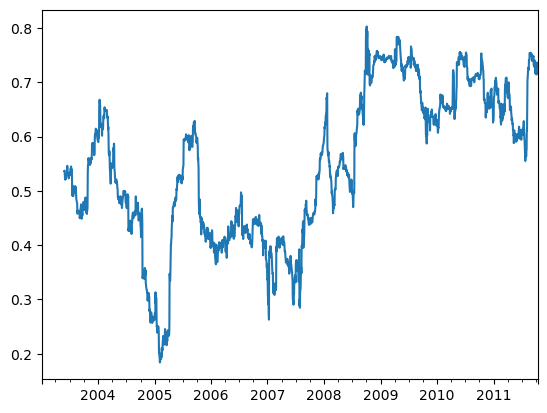

In [263]:
corr.plot()

Suppose you wanted to compute the correlation of the S&P 500 index with many
stocks at once. Writing a loop and creating a new DataFrame would be easy but might
get repetitive, so if you pass a Series and a DataFrame, a function like `rolling_corr`
will compute the correlation of the Series (`spx_rets`, in this case) with each column
in the DataFrame

In [264]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)

<Axes: >

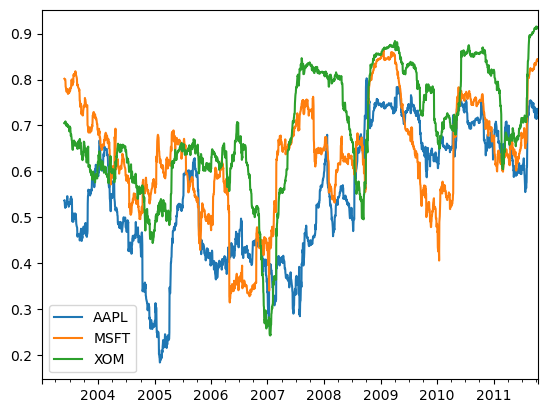

In [265]:
corr.plot()

### User-Defined Moving Window Functions

array function of your own devising over a moving window. The only requirement is
that the function produce a single value (a reduction) from each piece of the array.
For example, while we can compute sample quantiles using `rolling(...).quan
tile(q)`, we might be interested in the percentile rank of a particular value over the
sample. The `scipy.stats.percentileofscore` function does just this.

In [267]:
from scipy.stats import percentileofscore

In [268]:
score_at_2percent = lambda x: percentileofscore(x, 0.02)

In [269]:
result = returns.AAPL.rolling(250).apply(score_at_2percent)

In [270]:
result

2003-01-02     NaN
2003-01-03     NaN
2003-01-06     NaN
2003-01-07     NaN
2003-01-08     NaN
              ... 
2011-10-10    92.4
2011-10-11    92.0
2011-10-12    92.0
2011-10-13    92.0
2011-10-14    91.6
Freq: B, Name: AAPL, Length: 2292, dtype: float64

<Axes: >

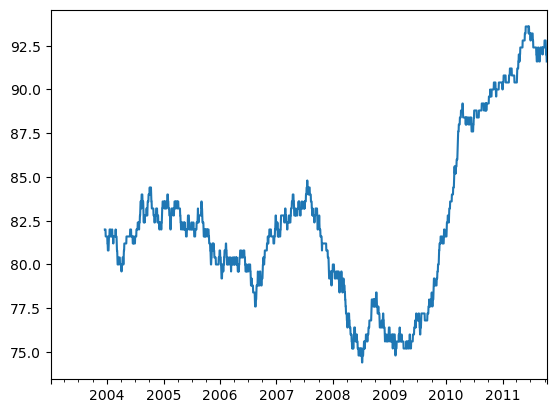

In [271]:
result.plot()

# 11.8 Conclusion

Time series data calls for different types of analysis and data transformation tools
than the other types of data we have explored in previous chapters.

In the following chapters, we will move on to some advanced pandas methods and
show how to start using modeling libraries like statsmodels and scikit-learn.

In [274]:
star_generator()

NameError: name 'star_generator' is not defined